<a href="https://colab.research.google.com/github/dee431/Central-Bank-Exchange-Rates-1914-to-today/blob/main/Central_Bank_Exchange_Rates%2C_1914_to_today.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
allratestoday_central_bank_exchange_rates_path = kagglehub.dataset_download('allratestoday/central-bank-exchange-rates')

print('Data source import complete.')


100%|██████████| 77.2M/77.2M [00:00<00:00, 198MB/s]

Extracting files...


Data source import complete.


# FX Volatility Regimes: Emerging Market Currencies Through Two Decades of Crises

This notebook studies how emerging-market currencies behave in calm and turbulent periods, using official central bank reference rates.

**Goal:** not to predict tomorrow's exchange rate (FX rates are close to a random walk), but to model *volatility* and detect *regimes*: when a currency moves from a calm state into a crisis state, how long it stays there, and whether crises spread across currencies.

**Roadmap**
1. Setup and dataset inventory
2. Scanning all sources and choosing the backbone dataset
3. The ECB dataset: structure, calendar and coverage
4. Data quality: redenominations, publication gaps and pegged currencies
5. Building the clean price panel
6. Exploratory analysis I: price levels and long-term trends
7. Exploratory analysis II: return distributions
8. Stylized facts: volatility clustering, autocorrelation and asymmetry
9. Stationarity tests
10. GARCH volatility modeling: model selection on TRY
11. Model diagnostics and out-of-sample VaR backtest
12. Regime detection with a Hidden Markov Model
13. Matching regimes to historical crises
14. Contagion: correlations and the dollar factor
15. Conclusions

## 1. Setup and Dataset Inventory

The dataset contains daily historical rates for 120 institutions (central banks, tax authorities and one composite source) as CSV files, plus a `latest_*.json` snapshot per source and a `sources.json` metadata file. We start by loading the metadata and taking stock of what is available.

> If you find this notebook useful, an upvote would be appreciated. If you fork it, please consider upvoting as well. Thanks!

In [2]:
import os, sys, glob, json, warnings, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from statsmodels.tsa.stattools import acf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# Install modeling libraries if they are not available in the environment
for package in ["arch", "hmmlearn"]:
    try:
        __import__(package)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

from arch import arch_model
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

In [4]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Locate the dataset folder wherever it is mounted
DATA_DIR = allratestoday_central_bank_exchange_rates_path
print("Data directory:", DATA_DIR)

# Metadata for every institution in the dataset
with open(os.path.join(DATA_DIR, "sources.json")) as f:
    sources = pd.DataFrame(json.load(f)).T.rename_axis("source").reset_index()

# File inventory: historical CSVs vs latest-snapshot JSONs
files = pd.DataFrame({"path": sorted(glob.glob(os.path.join(DATA_DIR, "*")))})
files["file"] = files["path"].map(os.path.basename)
files["ext"] = files["file"].str.split(".").str[-1]
files["size_mb"] = files["path"].map(os.path.getsize) / 1e6

print(f"\nInstitutions: {len(sources)}")
print(sources["kind"].value_counts().to_string())
print("\nFiles by type:")
print(files.groupby("ext").agg(n_files=("file", "count"), total_mb=("size_mb", "sum")).round(1))

csv_files = files[files["ext"] == "csv"].copy()
csv_files["source"] = csv_files["file"].str.replace(".csv", "", regex=False)
inventory = sources.merge(csv_files[["source", "size_mb"]], on="source", how="left")
inventory[["source", "name", "country", "home_currency", "kind", "size_mb"]] \
    .sort_values("size_mb", ascending=False).head(15).round(2)

Data directory: /root/.cache/kagglehub/datasets/allratestoday/central-bank-exchange-rates/versions/106

Institutions: 120
kind
central_bank     116
tax_authority      3
composite          1

Files by type:
      n_files  total_mb
ext                    
csv       120     549.6
json      122       0.6


,source,name,country,home_currency,kind,size_mb
77,composite,AllRatesToday Composite (official sources),Global,USD,composite,29.90
41,bojm,Bank of Jamaica,Jamaica,JMD,central_bank,27.99
6,bcb,Banco Central do Brasil (PTAX),Brazil,BRL,central_bank,26.22
95,nbrm,National Bank of North Macedonia,North Macedonia,MKD,central_bank,22.32
4,bazg,Swiss Federal Office for Customs and Border Se...,Switzerland,CHF,tax_authority,20.99
47,botz,Bank of Tanzania,Tanzania,TZS,central_bank,16.34
23,bdi,Banca d'Italia,Italy,EUR,central_bank,15.50
42,bok,Bank of Korea,South Korea,KRW,central_bank,14.89
64,cbk,Central Bank of Kuwait,Kuwait,KWD,central_bank,14.22
98,nbu,National Bank of Ukraine,Ukraine,UAH,central_bank,14.03


## 2. Scanning All Sources and Choosing the Backbone Dataset

Before picking which data to model, we scan every CSV and profile it: number of rows, first and last date, number of distinct trading days, how many foreign currencies it covers, which rate types it publishes (reference, buy/sell, middle, monthly averages...), and the quoting convention.

The quoting convention matters: a rate can be quoted as *home currency per 1 unit of foreign currency* (e.g. 40 TRY per 1 USD) or the other way around. Mixing conventions across sources would silently corrupt any comparison, so we measure the share of rows where the home currency is the base.

The goal is to find a source that is **long, daily, consistent in rate type and quoting convention, and covers several emerging-market currencies**.

Sources with less than 1 year of history : 15
Sources with 20+ years of history        : 40
Null values across all files             : 0
Zero or negative rates across all files  : 0
Sources quoting home currency as base    : 11
Sources with mixed quoting conventions   : 5


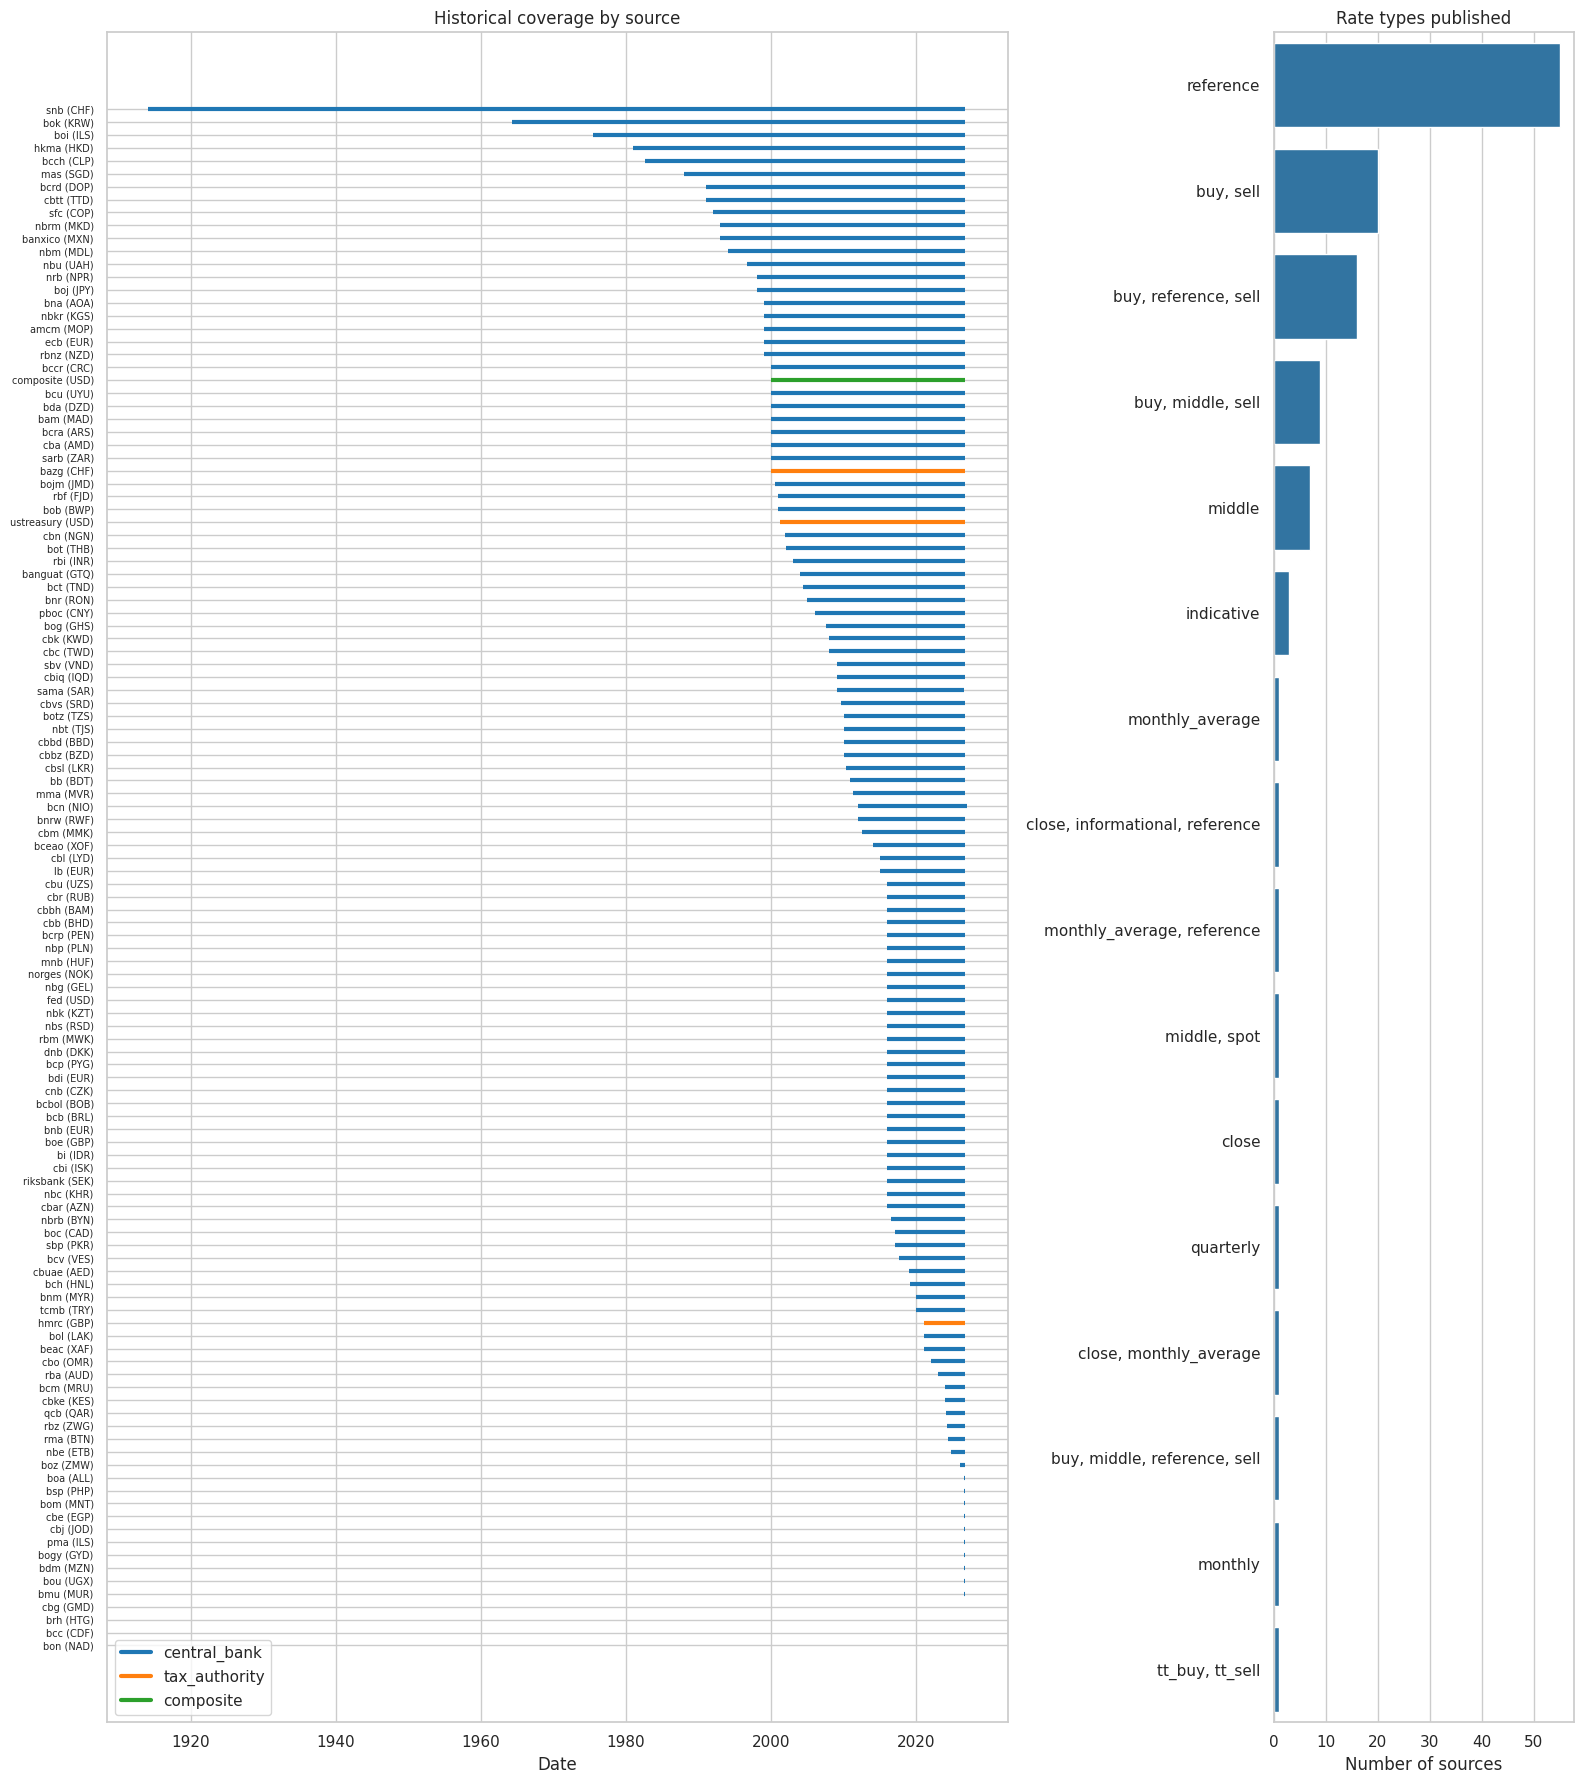

,source,country,home_currency,start,end,years,trading_days,n_currencies,rate_types,home_is_base
0,snb,Switzerland,CHF,1914-01-31,2026-08-31,112.6,1352,26,monthly_average,0.00
1,bok,South Korea,KRW,1964-05-04,2026-09-29,62.4,17156,52,reference,0.00
2,boi,Israel,ILS,1975-06-18,2026-09-29,51.3,13284,25,reference,0.00
3,hkma,Hong Kong,HKD,1981-01-02,2026-08-31,45.7,13456,22,reference,0.00
5,mas,Singapore,SGD,1988-01-08,2026-09-29,38.7,6741,21,reference,0.00
9,nbrm,North Macedonia,MKD,1993-01-01,2026-09-29,33.7,12317,48,"buy, reference, sell",0.00
11,nbm,Moldova,MDL,1994-01-01,2026-09-29,32.7,11950,45,reference,0.00
12,nbu,Ukraine,UAH,1996-09-02,2026-09-28,30.1,10950,45,reference,0.00
13,nrb,Nepal,NPR,1998-01-01,2026-09-29,28.7,9398,22,"buy, sell",0.00
15,bna,Angola,AOA,1998-12-31,2026-09-29,27.7,6753,70,"buy, reference, sell",0.00


In [5]:
records = []
for src, path in zip(csv_files["source"], csv_files["path"]):
    df = pd.read_csv(path, dtype={"base": "category", "quote": "category", "type": "category"})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    home = sources.loc[sources["source"] == src, "home_currency"].squeeze()
    foreign = np.where(df["base"] == home, df["quote"], df["base"])
    records.append({
        "source": src,
        "rows": len(df),
        "start": df["date"].min(),
        "end": df["date"].max(),
        "years": (df["date"].max() - df["date"].min()).days / 365.25,
        "trading_days": df["date"].nunique(),
        "n_currencies": pd.Series(foreign).nunique(),
        "rate_types": ", ".join(sorted(df["type"].astype(str).unique())),
        "home_is_base": round((df["base"] == home).mean(), 2),
        "null_values": df["value"].isna().sum(),
        "non_positive": (df["value"] <= 0).sum(),
    })

scan = sources[["source", "country", "home_currency", "kind"]].merge(pd.DataFrame(records), on="source")

print(f"Sources with less than 1 year of history : {(scan['years'] < 1).sum()}")
print(f"Sources with 20+ years of history        : {(scan['years'] >= 20).sum()}")
print(f"Null values across all files             : {scan['null_values'].sum()}")
print(f"Zero or negative rates across all files  : {scan['non_positive'].sum()}")
print(f"Sources quoting home currency as base    : {(scan['home_is_base'] == 1).sum()}")
print(f"Sources with mixed quoting conventions   : {scan['home_is_base'].between(0.01, 0.99).sum()}")

# Coverage timeline and rate-type distribution
scan = scan.sort_values("start").reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 18), gridspec_kw={"width_ratios": [3, 1]})
palette = {"central_bank": "#1f77b4", "tax_authority": "#ff7f0e", "composite": "#2ca02c"}

ax = axes[0]
for i, row in scan.iterrows():
    ax.hlines(i, row["start"], row["end"], color=palette[row["kind"]], lw=3)
ax.set_yticks(range(len(scan)))
ax.set_yticklabels(scan["source"] + " (" + scan["home_currency"] + ")", fontsize=7)
ax.invert_yaxis()
ax.set_title("Historical coverage by source")
ax.set_xlabel("Date")
for kind, color in palette.items():
    ax.plot([], [], color=color, lw=3, label=kind)
ax.legend(loc="lower left")

ax = axes[1]
type_counts = scan["rate_types"].value_counts()
sns.barplot(x=type_counts.values, y=type_counts.index, ax=ax, color="#1f77b4")
ax.set_title("Rate types published")
ax.set_xlabel("Number of sources")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Candidate backbone sources: long history, daily data, many currencies
candidates = scan[(scan["years"] >= 20) & (scan["n_currencies"] >= 20)]
candidates.sort_values("years", ascending=False)[
    ["source", "country", "home_currency", "start", "end", "years",
     "trading_days", "n_currencies", "rate_types", "home_is_base"]
].round({"years": 1})

## 3. The ECB Dataset: Structure, Calendar and Coverage

The scan points to the **European Central Bank** as the backbone: a single rate type (`reference`), a single quoting convention (1 EUR = x foreign currency), daily data since 1999 and 41 currencies including several emerging markets.

Before using it we check:
- **Duplicates**: each (date, currency) pair should appear only once.
- **Calendar**: the ECB publishes reference rates on TARGET business days, so weekends and TARGET holidays (1 Jan, Good Friday, Easter Monday, 1 May, 25-26 Dec) should be the only missing days.
- **Coverage per currency**: when each series starts and ends, and whether it has gaps in between. Several currencies disappear when their countries adopted the euro, and some were added later.

Rows: 221,035 | Columns: ['date', 'base', 'quote', 'type', 'value']
Rate types: ['reference'] | Base: ['EUR']
Duplicate (date, currency) pairs: 0

Price panel: 7,103 fixing days x 41 currencies

Business days in range: 7,237 | Missing: 134
Most common missing calendar dates (MM-DD):
05-01    20
12-26    20
12-25    19
01-01    19
04-21     4
04-18     4


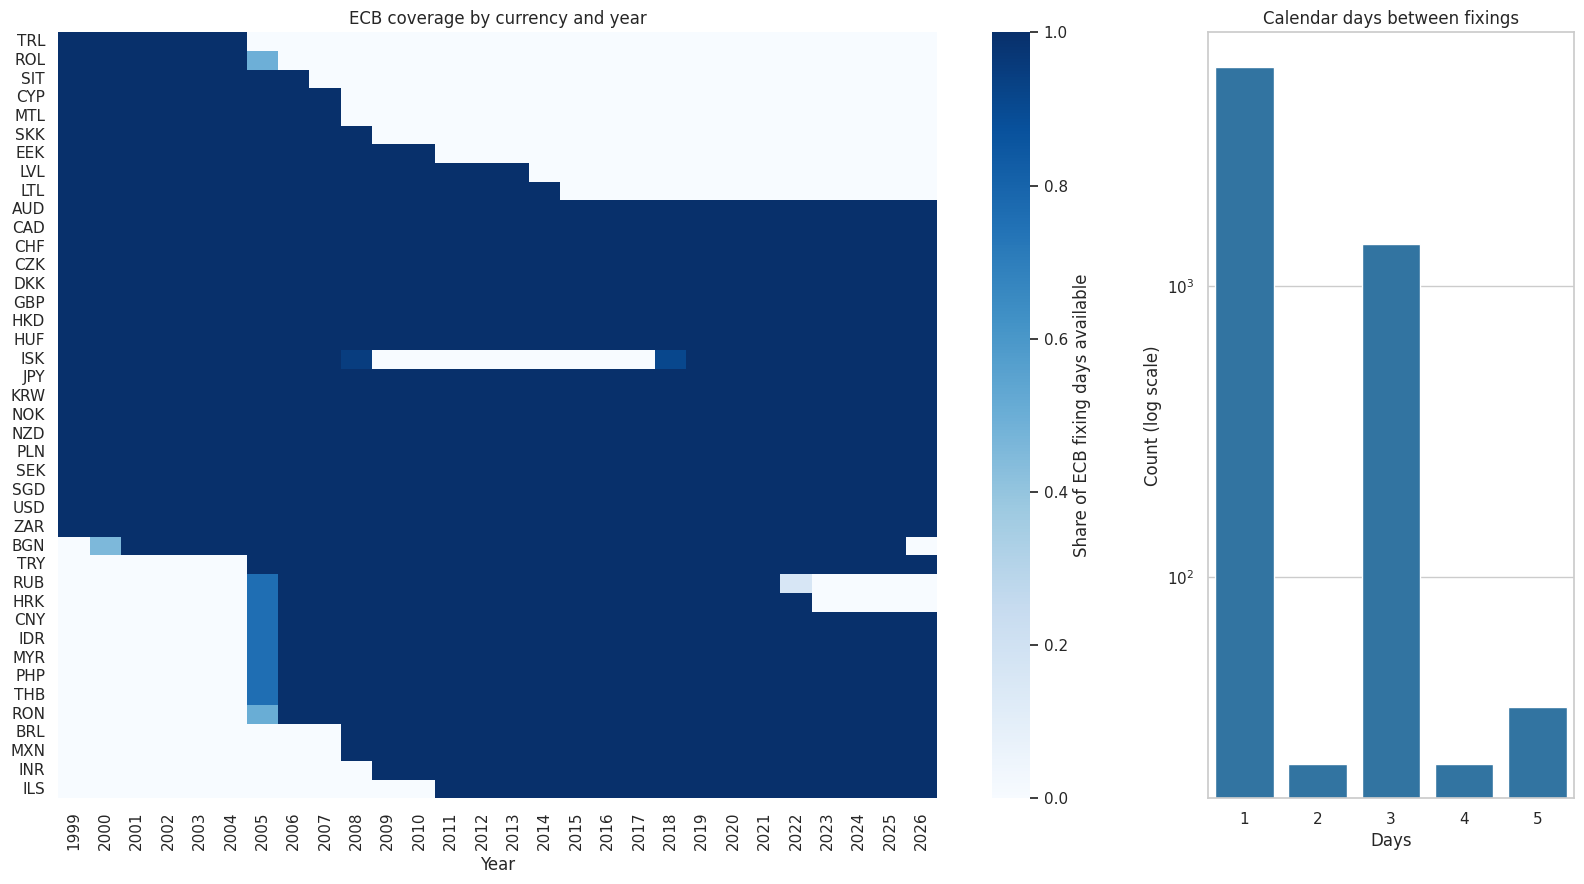

,start,end,obs,internal_gaps,active
quote,,,,,
TRL,1999-01-04,2004-12-31,1537,0,False
ROL,1999-01-04,2005-06-30,1664,0,False
SIT,1999-01-04,2006-12-29,2049,0,False
CYP,1999-01-04,2007-12-31,2304,0,False
MTL,1999-01-04,2007-12-31,2304,0,False
SKK,1999-01-04,2008-12-31,2560,0,False
EEK,1999-01-04,2010-12-31,3074,0,False
LVL,1999-01-04,2013-12-31,3842,0,False
LTL,1999-01-04,2014-12-31,4097,0,False


In [6]:
ecb = pd.read_csv(os.path.join(DATA_DIR, "ecb.csv"), parse_dates=["date"])
print(f"Rows: {len(ecb):,} | Columns: {list(ecb.columns)}")
print(f"Rate types: {ecb['type'].unique().tolist()} | Base: {ecb['base'].unique().tolist()}")
print(f"Duplicate (date, currency) pairs: {ecb.duplicated(['date', 'quote']).sum()}")

# Wide format: one row per fixing day, one column per currency
wide = ecb.pivot(index="date", columns="quote", values="value").sort_index()
print(f"\nPrice panel: {wide.shape[0]:,} fixing days x {wide.shape[1]} currencies")

# Calendar check: which business days are missing and why
bdays = pd.bdate_range(wide.index.min(), wide.index.max())
missing_bdays = bdays.difference(wide.index)
print(f"\nBusiness days in range: {len(bdays):,} | Missing: {len(missing_bdays)}")
print("Most common missing calendar dates (MM-DD):")
print(pd.Series(missing_bdays.strftime("%m-%d")).value_counts().head(6).to_string())

gaps = wide.index.to_series().diff().dt.days

# Coverage per currency
coverage = pd.DataFrame({
    "start": wide.apply(lambda s: s.first_valid_index()),
    "end": wide.apply(lambda s: s.last_valid_index()),
    "obs": wide.count(),
})
coverage["internal_gaps"] = [wide.loc[r.start:r.end, c].isna().sum() for c, r in coverage.iterrows()]
coverage["active"] = coverage["end"] >= wide.index.max() - pd.Timedelta(days=30)
coverage = coverage.sort_values(["start", "end"])

# Coverage heatmap and spacing between fixings
year_cov = wide.notna().groupby(wide.index.year).mean().T.loc[coverage.index]
fig, axes = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={"width_ratios": [3, 1]})
sns.heatmap(year_cov, cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "Share of ECB fixing days available"}, ax=axes[0])
axes[0].set_title("ECB coverage by currency and year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("")

gap_counts = gaps.dropna().astype(int).value_counts().sort_index()
sns.barplot(x=gap_counts.index.astype(str), y=gap_counts.values, ax=axes[1], color="#1f77b4")
axes[1].set_yscale("log")
axes[1].set_title("Calendar days between fixings")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Count (log scale)")
plt.tight_layout()
plt.show()

coverage

## 4. Data Quality: Redenominations, Publication Gaps and Pegged Currencies

Three issues must be handled before any return or volatility is computed:

**1. Redenominations.** Turkey removed six zeros from the lira on 1 January 2005 (1 TRY = 1,000,000 TRL) and Romania removed four on 1 July 2005 (1 RON = 10,000 ROL). The ECB publishes the old and new codes as separate series. Treated naively, the switch would look like a 99.9999% appreciation in a single day. We rescale the old series and splice it onto the new one, then check that the return across the switch is ordinary.

**2. Publication gaps.** The ECB stopped publishing the Icelandic krona during the 2008 banking crisis and resumed in 2018. The return across that gap is not a daily return and must never be computed or forward-filled.

**3. Pegged currencies.** A currency pegged to the euro (or to the dollar) barely moves against its anchor. Its volatility is a policy choice, not a market outcome, so it adds nothing to a volatility-regime study. We detect pegs empirically by measuring each currency's annualized volatility against both EUR and USD: a peg shows up as near-zero volatility against one of them.

TRL -> TRY: last TRL/1,000,000 on 2004-12-31 = 1.8362 | first TRY on 2005-01-03 = 1.8150 | move across switch: -1.16%
ROL -> RON: last ROL/10,000 on 2005-06-30 = 3.6030 | first RON on 2005-07-01 = 3.6030 | move across switch: +0.00%

ISK not published from 2008-12-10 to 2018-01-31 (2,341 fixing days)
Last value before gap: 290.00 | first value after gap: 125.01

Currencies with annualized volatility below 2.0% against an anchor:
       vol_vs_EUR  vol_vs_USD  min_vol anchor
quote                                        
EEK          0.00       10.62     0.00    EUR
DKK          0.23        9.20     0.23    EUR
BGN          0.33        9.19     0.33    EUR
HKD          9.15        0.86     0.86    USD
CYP          0.90        9.66     0.90    EUR
HRK          1.87        9.30     1.87    EUR


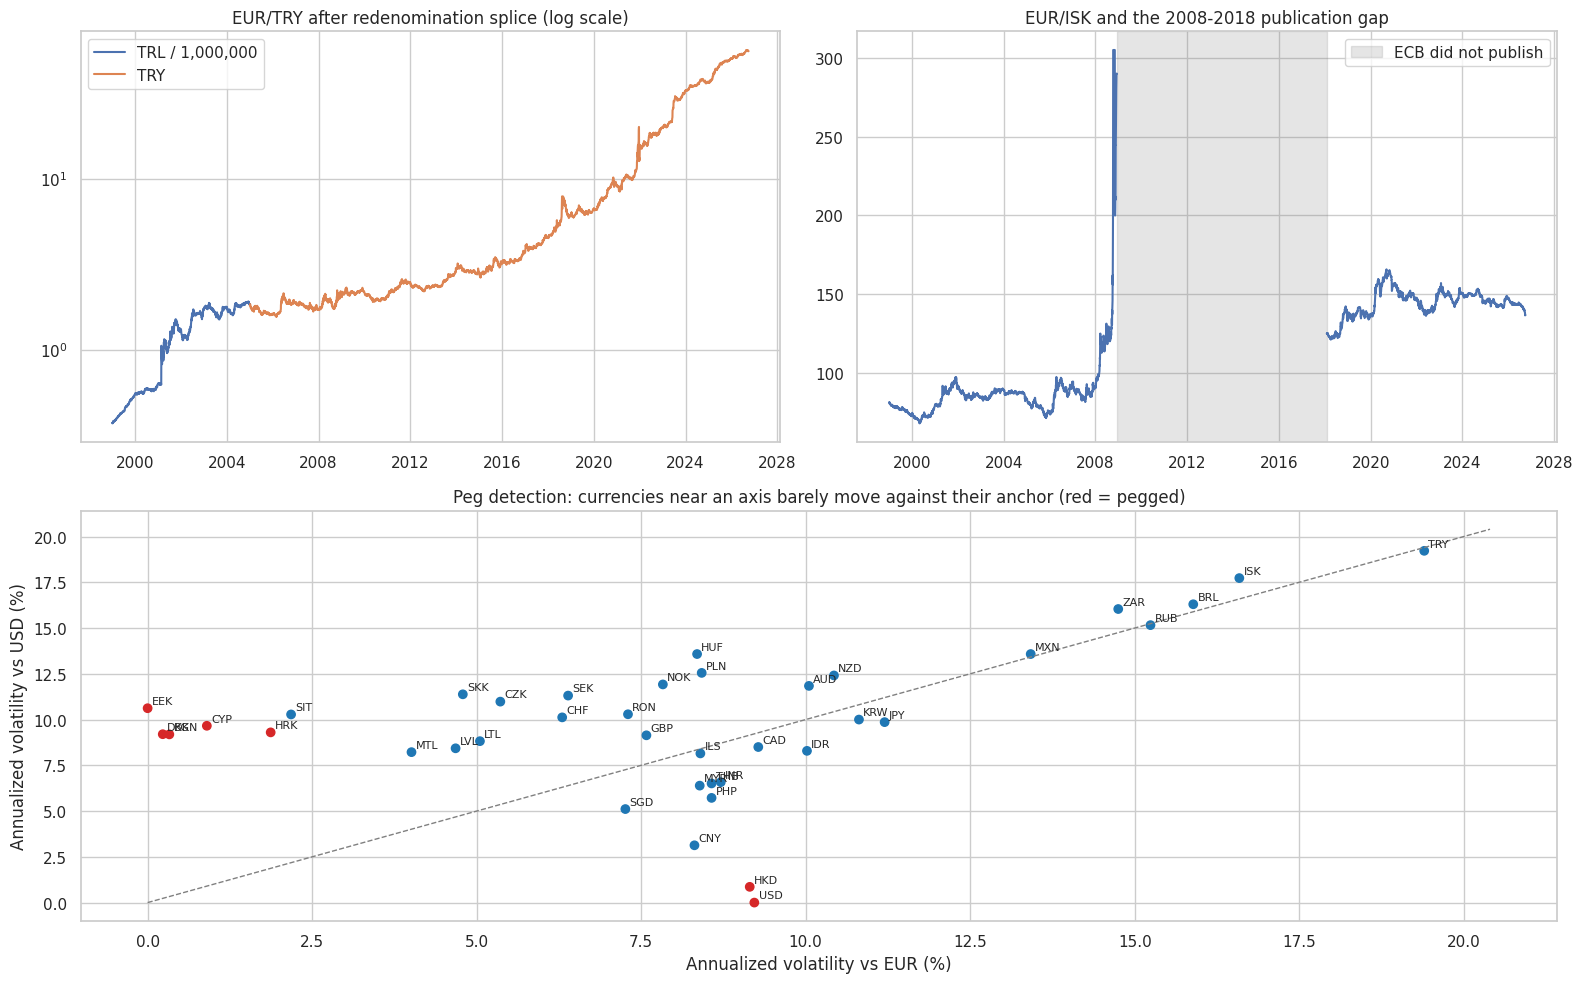

In [7]:
# 1. Splice redenominated currencies onto their successors
REDENOMINATIONS = {"TRY": ("TRL", 1_000_000), "RON": ("ROL", 10_000)}

for new, (old, factor) in REDENOMINATIONS.items():
    last_old = wide[old].dropna()
    first_new = wide[new].dropna()
    old_rescaled = last_old.iloc[-1] / factor
    jump = np.log(first_new.iloc[0] / old_rescaled) * 100
    print(f"{old} -> {new}: last {old}/{factor:,} on {last_old.index[-1].date()} = {old_rescaled:.4f} | "
          f"first {new} on {first_new.index[0].date()} = {first_new.iloc[0]:.4f} | move across switch: {jump:+.2f}%")
    wide[new] = wide[new].fillna(wide[old] / factor)
    wide = wide.drop(columns=old)

# 2. Locate the ISK publication gap
isk = wide["ISK"]
isk_gap = isk[isk.isna() & isk.ffill().notna() & isk.bfill().notna()].index
print(f"\nISK not published from {isk_gap.min().date()} to {isk_gap.max().date()} ({len(isk_gap):,} fixing days)")
print(f"Last value before gap: {isk.loc[:isk_gap.min()].dropna().iloc[-1]:.2f} | "
      f"first value after gap: {isk.loc[isk_gap.max():].dropna().iloc[0]:.2f}")

# 3. Peg detection: volatility against EUR and against USD
log_ret_eur = np.log(wide).diff()
per_usd = wide.div(wide["USD"], axis=0)
log_ret_usd = np.log(per_usd).diff()

peg_table = pd.DataFrame({
    "vol_vs_EUR": log_ret_eur.std() * np.sqrt(252) * 100,
    "vol_vs_USD": log_ret_usd.std() * np.sqrt(252) * 100,
}).round(2)
peg_table["min_vol"] = peg_table.min(axis=1)
peg_table["anchor"] = np.where(peg_table["vol_vs_EUR"] < peg_table["vol_vs_USD"], "EUR", "USD")
PEG_THRESHOLD = 2.0
pegged = peg_table[(peg_table["min_vol"] < PEG_THRESHOLD) & (peg_table.index != "USD")]
print(f"\nCurrencies with annualized volatility below {PEG_THRESHOLD}% against an anchor:")
print(pegged.sort_values("min_vol").to_string())

# Visual checks
fig = plt.figure(figsize=(16, 10))
grid = fig.add_gridspec(2, 2)

ax = fig.add_subplot(grid[0, 0])
ax.plot(wide["TRY"].loc[:"2004-12-31"], label="TRL / 1,000,000")
ax.plot(wide["TRY"].loc["2005-01-01":], label="TRY")
ax.set_yscale("log")
ax.set_title("EUR/TRY after redenomination splice (log scale)")
ax.legend()

ax = fig.add_subplot(grid[0, 1])
ax.plot(wide["ISK"])
ax.axvspan(isk_gap.min(), isk_gap.max(), color="grey", alpha=0.2, label="ECB did not publish")
ax.set_title("EUR/ISK and the 2008-2018 publication gap")
ax.legend()

ax = fig.add_subplot(grid[1, :])
colors = np.where(peg_table["min_vol"] < PEG_THRESHOLD, "#d62728", "#1f77b4")
ax.scatter(peg_table["vol_vs_EUR"], peg_table["vol_vs_USD"], color=colors)
for ccy, row in peg_table.iterrows():
    ax.annotate(ccy, (row["vol_vs_EUR"], row["vol_vs_USD"]), fontsize=8,
                xytext=(3, 3), textcoords="offset points")
lim = peg_table[["vol_vs_EUR", "vol_vs_USD"]].max().max() + 1
ax.plot([0, lim], [0, lim], ls="--", color="grey", lw=1)
ax.set_xlabel("Annualized volatility vs EUR (%)")
ax.set_ylabel("Annualized volatility vs USD (%)")
ax.set_title("Peg detection: currencies near an axis barely move against their anchor (red = pegged)")
plt.tight_layout()
plt.show()

## 5. Building the Clean Price Panel

Based on the quality checks, the final panel follows these rules:

- **Excluded, pegged:** currencies with less than 2% annualized volatility against their anchor (EEK, DKK, BGN, CYP, HRK against EUR; HKD against USD).
- **Excluded, discontinued:** currencies no longer published (legacy euro-adopter currencies and RUB, which the ECB stopped publishing in March 2022).
- **Excluded, gap:** ISK, because its nine-year publication gap (December 2008 to January 2018) starts in the middle of the 2008 Icelandic crisis and hides the entire period that followed.

**Quoting base.** ECB rates are quoted per euro. Emerging-market currencies, however, trade and are analysed against the US dollar, so we convert every series to *units of currency per 1 USD* using the ECB's own EUR/USD fixing (all rates are fixed at the same time, so the cross rates are consistent). The euro itself enters the panel as EUR per USD. Under this convention, **a rising series means the currency is depreciating against the dollar**.

The choice of base changes the correlation structure: a USD base exposes the common "dollar factor" that drives currencies together during global risk-off episodes, which is exactly what the contagion analysis later needs. We verify this by comparing average pairwise correlations under both bases.

**Groups.** Currencies are split into emerging markets (EM) and developed markets (DM), broadly following the MSCI classification. Romania, a frontier market in MSCI, is grouped with its Central European peers because its currency behaves like theirs, as the clustering in Section 14 confirms.

Excluded as pegged       : ['BGN', 'CYP', 'DKK', 'EEK', 'HKD', 'HRK']
Excluded as discontinued : ['LTL', 'LVL', 'MTL', 'RUB', 'SIT', 'SKK']
Excluded for data gap    : ['ISK']

Clean panel: 7,103 days x 26 currencies (15 EM, 11 DM)


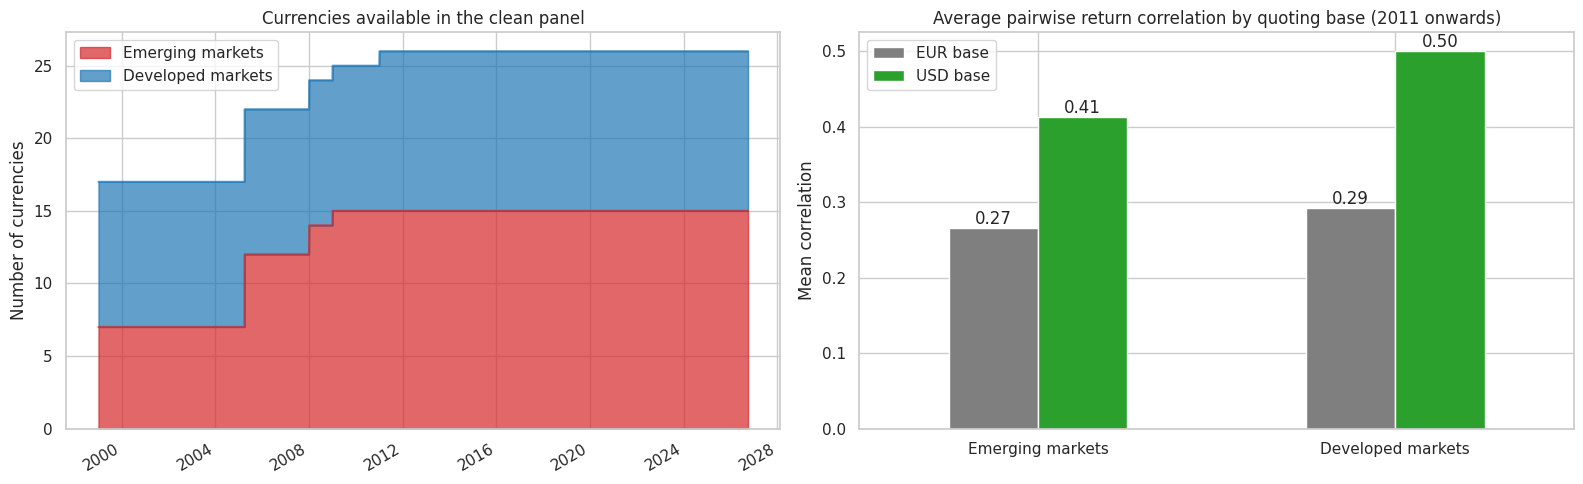

,group,start,obs,first_value,last_value,total_change_%
quote,,,,,,
BRL,EM,2008-01-02,4799,1.771,5.212,194.299
MXN,EM,2008-01-02,4799,10.903,17.897,64.149
ZAR,EM,1999-01-04,7103,5.883,16.370,178.255
TRY,EM,1999-01-04,7103,0.316,49.000,15417.176
INR,EM,2009-01-02,4543,48.410,95.985,98.276
IDR,EM,2005-04-01,5504,9469.998,17921.700,89.247
KRW,EM,1999-01-04,7103,1186.352,1353.360,14.077
CNY,EM,2005-04-01,5504,8.276,6.703,-19.007
THB,EM,2005-04-01,5504,39.158,33.515,-14.412


In [8]:
EXCLUDE_PEGGED = pegged.index.tolist()
EXCLUDE_DISCONTINUED = coverage[~coverage["active"]].index.intersection(wide.columns).tolist()
EXCLUDE_GAP = ["ISK"]
print("Excluded as pegged       :", sorted(EXCLUDE_PEGGED))
print("Excluded as discontinued :", sorted(set(EXCLUDE_DISCONTINUED) - set(EXCLUDE_PEGGED)))
print("Excluded for data gap    :", EXCLUDE_GAP)

EM = ["BRL", "MXN", "ZAR", "TRY", "INR", "IDR", "KRW", "CNY", "THB", "MYR", "PHP", "PLN", "HUF", "CZK", "RON"]
DM = ["EUR", "JPY", "GBP", "CHF", "AUD", "CAD", "NZD", "NOK", "SEK", "SGD", "ILS"]

# Convert every series to units of currency per 1 USD
prices = wide.div(wide["USD"], axis=0)
prices["EUR"] = 1 / wide["USD"]
prices = prices[EM + DM]

# Daily log returns between consecutive fixing days
returns = np.log(prices).diff()

panel_summary = pd.DataFrame({
    "group": ["EM" if c in EM else "DM" for c in prices.columns],
    "start": prices.apply(lambda s: s.first_valid_index().date()),
    "obs": prices.count(),
    "first_value": prices.apply(lambda s: s.dropna().iloc[0]),
    "last_value": prices.iloc[-1],
})
panel_summary["total_change_%"] = (panel_summary["last_value"] / panel_summary["first_value"] - 1) * 100
print(f"\nClean panel: {prices.shape[0]:,} days x {prices.shape[1]} currencies ({len(EM)} EM, {len(DM)} DM)")

# Does the quoting base change the correlation structure?
eur_based = np.log(wide[[c for c in EM + DM if c != "EUR"]]).diff()
dm_ex_eur = [c for c in DM if c != "EUR"]
common = slice("2011-01-03", None)

def mean_pairwise_corr(r):
    c = r.corr().values
    return c[np.triu_indices_from(c, k=1)].mean()

corr_compare = pd.DataFrame({
    "EUR base": [mean_pairwise_corr(eur_based.loc[common, EM]), mean_pairwise_corr(eur_based.loc[common, dm_ex_eur])],
    "USD base": [mean_pairwise_corr(returns.loc[common, EM]), mean_pairwise_corr(returns.loc[common, dm_ex_eur])],
}, index=["Emerging markets", "Developed markets"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
availability = pd.DataFrame({
    "Emerging markets": prices[EM].notna().sum(axis=1),
    "Developed markets": prices[DM].notna().sum(axis=1),
})
availability.plot.area(ax=axes[0], alpha=0.7, color=["#d62728", "#1f77b4"])
axes[0].set_title("Currencies available in the clean panel")
axes[0].set_ylabel("Number of currencies")
axes[0].set_xlabel("")

corr_compare.plot.bar(ax=axes[1], rot=0, color=["#7f7f7f", "#2ca02c"])
axes[1].set_title("Average pairwise return correlation by quoting base (2011 onwards)")
axes[1].set_ylabel("Mean correlation")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f")
plt.tight_layout()
plt.show()

panel_summary.round(3)

## 6. Exploratory Analysis I: Price Levels and Long-Term Trends

We first look at how each currency has moved against the dollar over the common window, starting on 3 January 2011, the first day on which all 26 currencies are available.

To make currencies with very different price levels comparable (1 USD is about 1.4 AUD but about 17,800 IDR), each series is rebased to 100 on the start date and plotted on a log scale, so equal vertical distances mean equal percentage moves.

We then summarise the long-run trend as an **annualized rate of change** (compound annual growth rate of units per USD). A positive value means the currency lost value against the dollar on average each year.

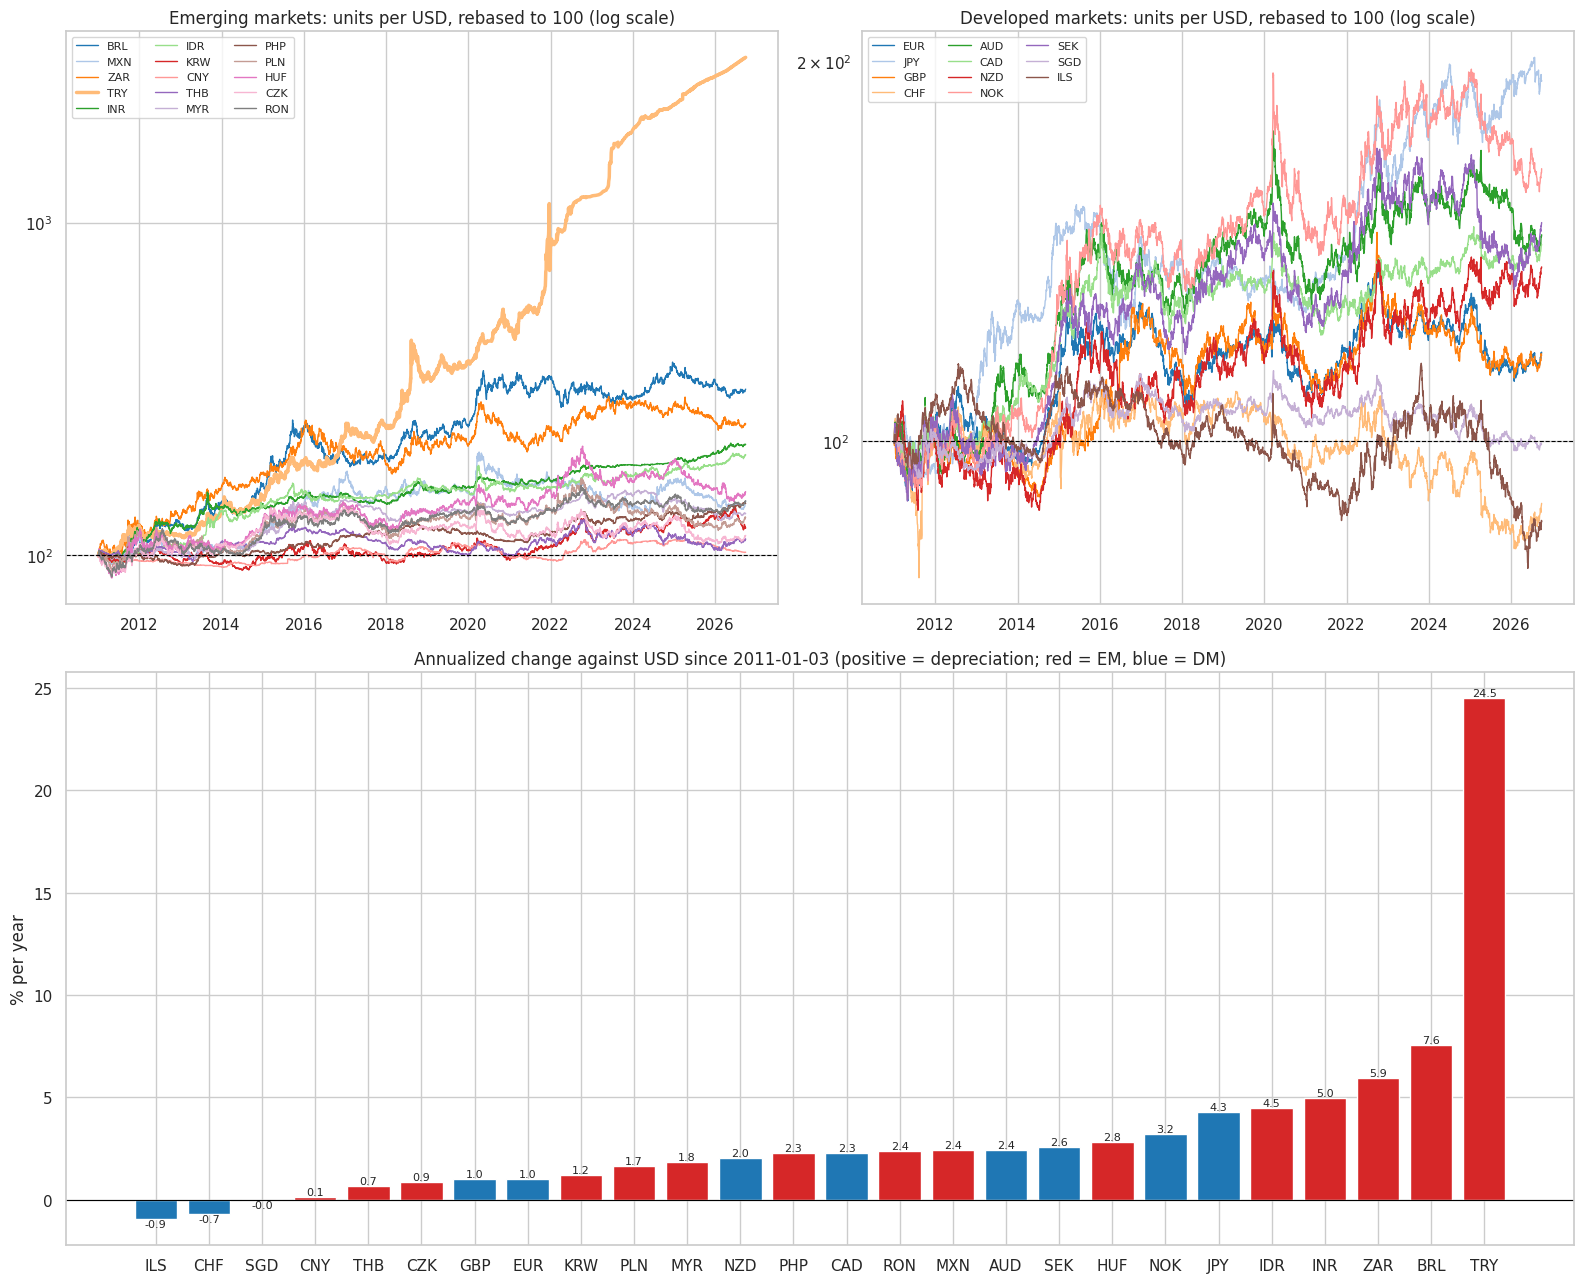

,worst_day_%,worst_day,best_day_%,best_day,annualized_change_%
quote,,,,,
TRY,13.11,2018-08-13,-31.11,2021-12-21,24.49
BRL,6.04,2017-05-19,-7.85,2015-09-25,7.57
ZAR,4.85,2016-08-24,-5.17,2016-03-17,5.93
INR,4.33,2013-08-27,-2.98,2013-08-29,4.99
IDR,4.23,2013-10-18,-4.08,2013-10-21,4.49
JPY,3.24,2011-08-04,-4.60,2024-08-05,4.26
NOK,6.35,2020-03-19,-4.44,2022-11-11,3.21
HUF,4.74,2022-02-24,-3.71,2012-04-25,2.81
SEK,4.56,2016-06-24,-4.89,2022-11-11,2.56


In [9]:
BASE_DATE = "2011-01-03"

rebased = prices.loc[BASE_DATE:] / prices.loc[BASE_DATE] * 100
n_years = (prices.index[-1] - pd.Timestamp(BASE_DATE)).days / 365.25
annualized_change = ((prices.iloc[-1] / prices.loc[BASE_DATE]) ** (1 / n_years) - 1) * 100

# Largest single-day moves within the window
window_returns = returns.loc[BASE_DATE:]
extremes = pd.DataFrame({
    "worst_day_%": window_returns.max() * 100,
    "worst_day": window_returns.idxmax().dt.date,
    "best_day_%": window_returns.min() * 100,
    "best_day": window_returns.idxmin().dt.date,
    "annualized_change_%": annualized_change,
}).round(2)

fig = plt.figure(figsize=(16, 13))
grid = fig.add_gridspec(2, 2)
palette = plt.cm.tab20.colors

for i, (group_name, cols) in enumerate([("Emerging markets", EM), ("Developed markets", DM)]):
    ax = fig.add_subplot(grid[0, i])
    for j, ccy in enumerate(cols):
        ax.plot(rebased[ccy], lw=2.5 if ccy == "TRY" else 1, color=palette[j], label=ccy)
    ax.set_yscale("log")
    ax.axhline(100, color="black", lw=0.8, ls="--")
    ax.set_title(f"{group_name}: units per USD, rebased to 100 (log scale)")
    ax.legend(ncol=3, fontsize=8)

ax = fig.add_subplot(grid[1, :])
ordered = annualized_change.sort_values()
colors = ["#d62728" if c in EM else "#1f77b4" for c in ordered.index]
ax.bar(ordered.index, ordered.values, color=colors)
ax.axhline(0, color="black", lw=0.8)
for x, v in zip(ordered.index, ordered.values):
    ax.annotate(f"{v:.1f}", (x, v), ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
ax.set_title(f"Annualized change against USD since {BASE_DATE} (positive = depreciation; red = EM, blue = DM)")
ax.set_ylabel("% per year")
plt.tight_layout()
plt.show()

extremes.sort_values("annualized_change_%", ascending=False)

## 7. Exploratory Analysis II: Return Distributions

Volatility models are built on returns, not prices, so we now study the distribution of daily log returns for each currency over its full available history.

For each currency we compute:
- **Annualized volatility**: daily standard deviation multiplied by the square root of 252 trading days.
- **Skewness**: asymmetry of the distribution. With our convention (units per USD), positive skew means large depreciations are more common than large appreciations.
- **Excess kurtosis**: tail thickness relative to a normal distribution (0 for a normal).
- **Jarque-Bera test**: a formal test of normality based on skewness and kurtosis.
- **Share of days beyond 4 standard deviations**: under a normal distribution this should happen on about 0.006% of days, roughly once every 60 years.

We also check how returns over weekends and holidays (3 or more calendar days between fixings) compare with ordinary one-day returns. If information flowed at the same rate on closed days, a 3-day return would be about 1.7 times (the square root of 3) as volatile as a 1-day return.

Expected share beyond 4 SD under normality: 0.0063%
Volatility ratio, 3-day vs 1-day returns: mean 1.05, range 0.83 to 1.16 (square root of 3 = 1.73)


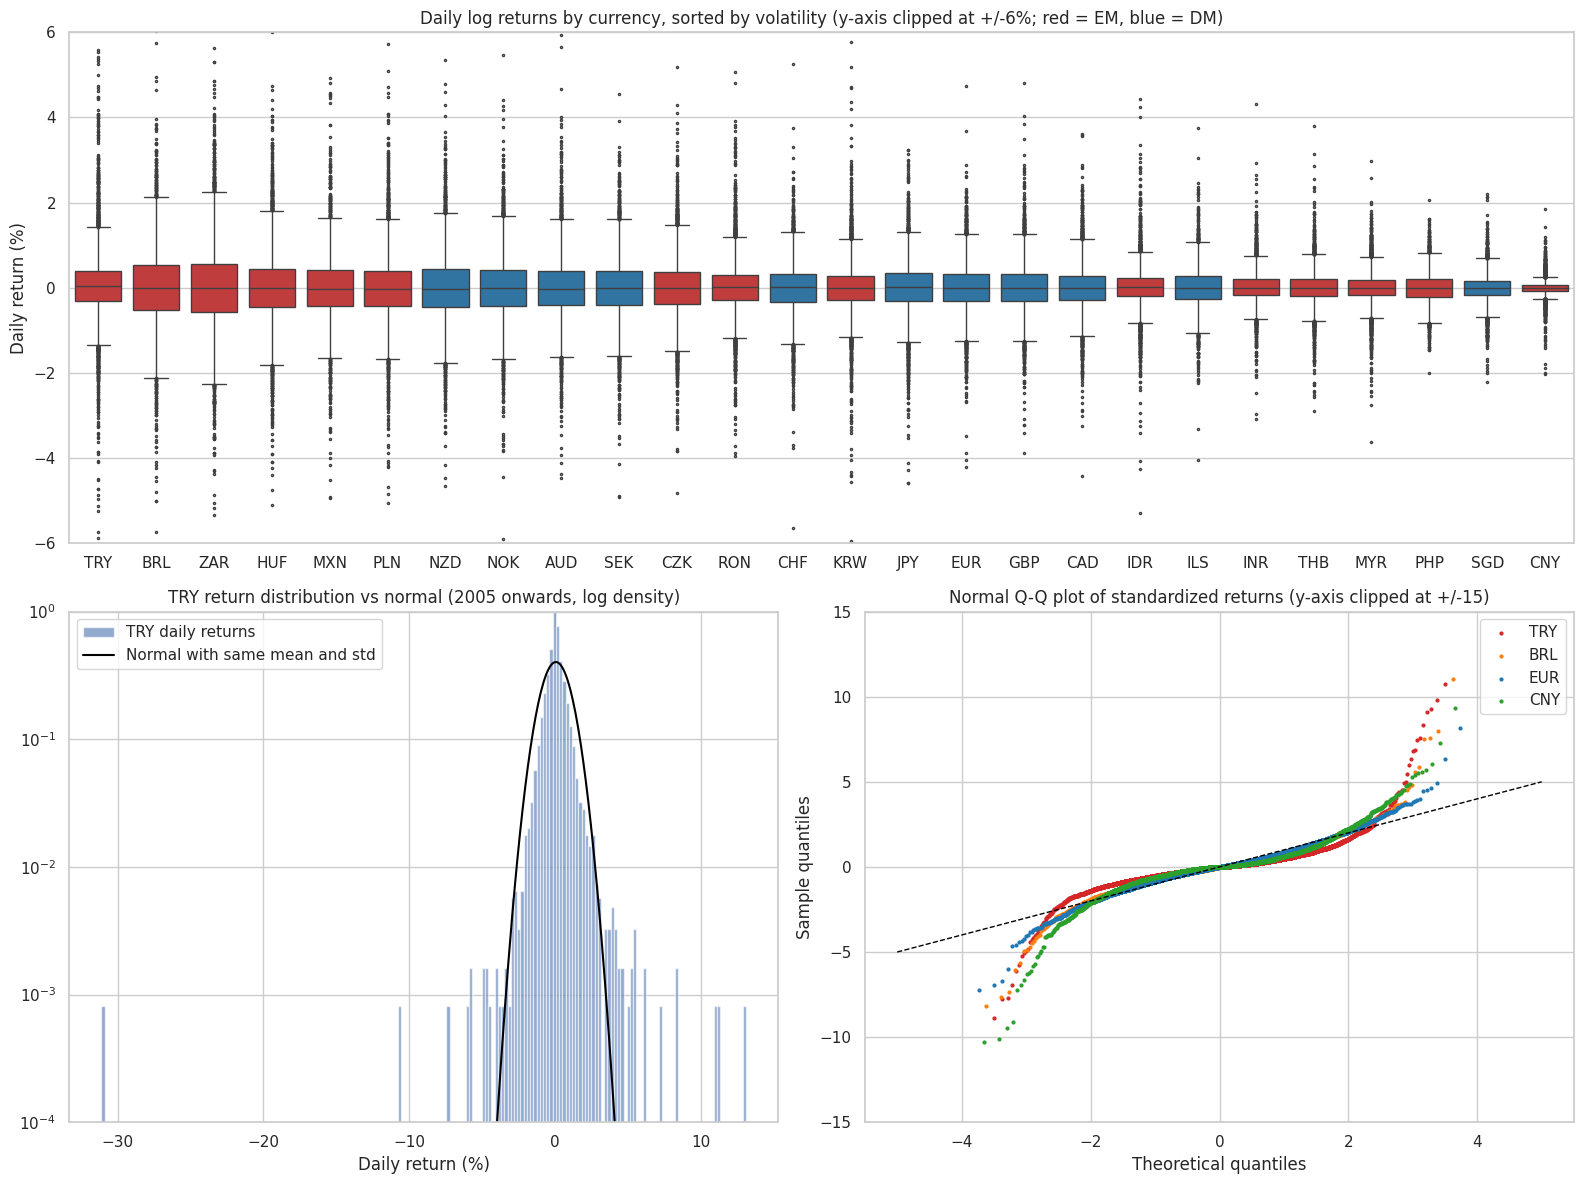

,group,obs,mean_daily_%,ann_vol_%,skew,excess_kurtosis,min_%,max_%,jarque_bera,jb_pvalue,beyond_4sd_%
quote,,,,,,,,,,,
TRY,EM,7102,0.071,19.225,10.015,585.148,-31.110,52.970,1.012973e+08,0.0,0.521
BRL,EM,4798,0.022,16.300,0.317,9.506,-8.363,11.378,1.810473e+04,0.0,0.310
ZAR,EM,7102,0.014,16.044,0.375,4.205,-8.153,8.526,5.388794e+03,0.0,0.338
HUF,EM,7102,0.006,13.584,0.261,3.836,-5.104,6.534,4.427321e+03,0.0,0.394
MXN,EM,4798,0.010,13.576,0.935,14.762,-7.314,11.233,4.416748e+04,0.0,0.352
PLN,EM,7102,0.002,12.552,0.340,4.831,-5.056,6.784,7.030438e+03,0.0,0.521
NZD,DM,7102,-0.001,12.412,0.315,3.312,-4.654,6.288,3.356234e+03,0.0,0.366
NOK,DM,7102,0.003,11.919,0.145,3.762,-5.917,6.350,4.205713e+03,0.0,0.352
AUD,DM,7102,-0.002,11.840,0.304,6.066,-7.195,7.374,1.098065e+04,0.0,0.465


In [10]:
r = returns * 100

desc = pd.DataFrame({
    "group": ["EM" if c in EM else "DM" for c in r.columns],
    "obs": r.count(),
    "mean_daily_%": r.mean(),
    "ann_vol_%": r.std() * np.sqrt(252),
    "skew": r.skew(),
    "excess_kurtosis": r.kurt(),
    "min_%": r.min(),
    "max_%": r.max(),
})
jb = {c: stats.jarque_bera(r[c].dropna()) for c in r.columns}
desc["jarque_bera"] = [jb[c].statistic for c in r.columns]
desc["jb_pvalue"] = [jb[c].pvalue for c in r.columns]
desc["beyond_4sd_%"] = [(np.abs((r[c] - r[c].mean()) / r[c].std()) > 4).mean() * 100 for c in r.columns]
print(f"Expected share beyond 4 SD under normality: {2 * stats.norm.sf(4) * 100:.4f}%")

# Weekend and holiday effect: volatility by calendar days between fixings
gap_days = r.index.to_series().diff().dt.days
weekend_ratio = r[gap_days == 3].std() / r[gap_days == 1].std()
print(f"Volatility ratio, 3-day vs 1-day returns: mean {weekend_ratio.mean():.2f}, "
      f"range {weekend_ratio.min():.2f} to {weekend_ratio.max():.2f} (square root of 3 = {np.sqrt(3):.2f})")

order = desc.sort_values("ann_vol_%", ascending=False).index
fig = plt.figure(figsize=(16, 12))
grid = fig.add_gridspec(2, 2)

ax = fig.add_subplot(grid[0, :])
long = r[order].melt(var_name="currency", value_name="return").dropna()
sns.boxplot(data=long, x="currency", y="return", order=order, hue="currency", legend=False, ax=ax,
            fliersize=1.5, palette=["#d62728" if c in EM else "#1f77b4" for c in order])
ax.set_ylim(-6, 6)
ax.set_title("Daily log returns by currency, sorted by volatility (y-axis clipped at +/-6%; red = EM, blue = DM)")
ax.set_ylabel("Daily return (%)")
ax.set_xlabel("")

ax = fig.add_subplot(grid[1, 0])
try_ret = r["TRY"].loc["2005":].dropna()
ax.hist(try_ret, bins=200, density=True, alpha=0.6, label="TRY daily returns")
xs = np.linspace(try_ret.min(), try_ret.max(), 500)
ax.plot(xs, stats.norm.pdf(xs, try_ret.mean(), try_ret.std()), color="black", label="Normal with same mean and std")
ax.set_yscale("log")
ax.set_ylim(1e-4, 1)
ax.set_title("TRY return distribution vs normal (2005 onwards, log density)")
ax.set_xlabel("Daily return (%)")
ax.legend()

ax = fig.add_subplot(grid[1, 1])
for ccy, color in zip(["TRY", "BRL", "EUR", "CNY"], ["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"]):
    z = r[ccy].dropna()
    z = (z - z.mean()) / z.std()
    (theoretical, sample), _ = stats.probplot(z, dist="norm")
    ax.scatter(theoretical, sample, s=4, color=color, label=ccy)
ax.plot([-5, 5], [-5, 5], color="black", lw=1, ls="--")
ax.set_ylim(-15, 15)
ax.set_title("Normal Q-Q plot of standardized returns (y-axis clipped at +/-15)")
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.legend()
plt.tight_layout()
plt.show()

desc.sort_values("ann_vol_%", ascending=False).round(3)

## 8. Stylized Facts: Volatility Clustering, Autocorrelation and Asymmetry

Financial returns share a set of well-documented empirical regularities, known as *stylized facts*. Checking them tells us which model features we actually need.

1. **Returns are nearly unpredictable.** Autocorrelation of returns should be close to zero. If it were strong, simple trading rules would be profitable.
2. **Volatility is predictable.** Large moves tend to be followed by large moves of either sign (*volatility clustering*). This shows up as strong, slowly decaying autocorrelation in *absolute* returns.
3. **Asymmetry.** For equities, falling prices raise future volatility (the *leverage effect*). For currencies the question is: does a depreciation against the dollar raise future volatility more than an appreciation? We measure this as the correlation between today's return and tomorrow's absolute return.

Formal tests:
- **Ljung-Box test** (10 lags) on returns and on absolute returns. The null hypothesis is no autocorrelation.
- **Engle's ARCH-LM test** (5 lags). The null hypothesis is no conditional heteroskedasticity, i.e. constant volatility.

We use absolute rather than squared returns for the autocorrelation analysis, because squared returns are dominated by a handful of extreme days (such as the 2001 lira float or the 2015 Swiss franc shock).

Currencies with significant return autocorrelation (5%)   : 20 / 26
Currencies with significant volatility clustering (5%)    : 26 / 26
Currencies where ARCH-LM rejects constant volatility (5%) : 25 / 26
Mean lag-1 autocorrelation: returns -0.010 | absolute returns 0.204


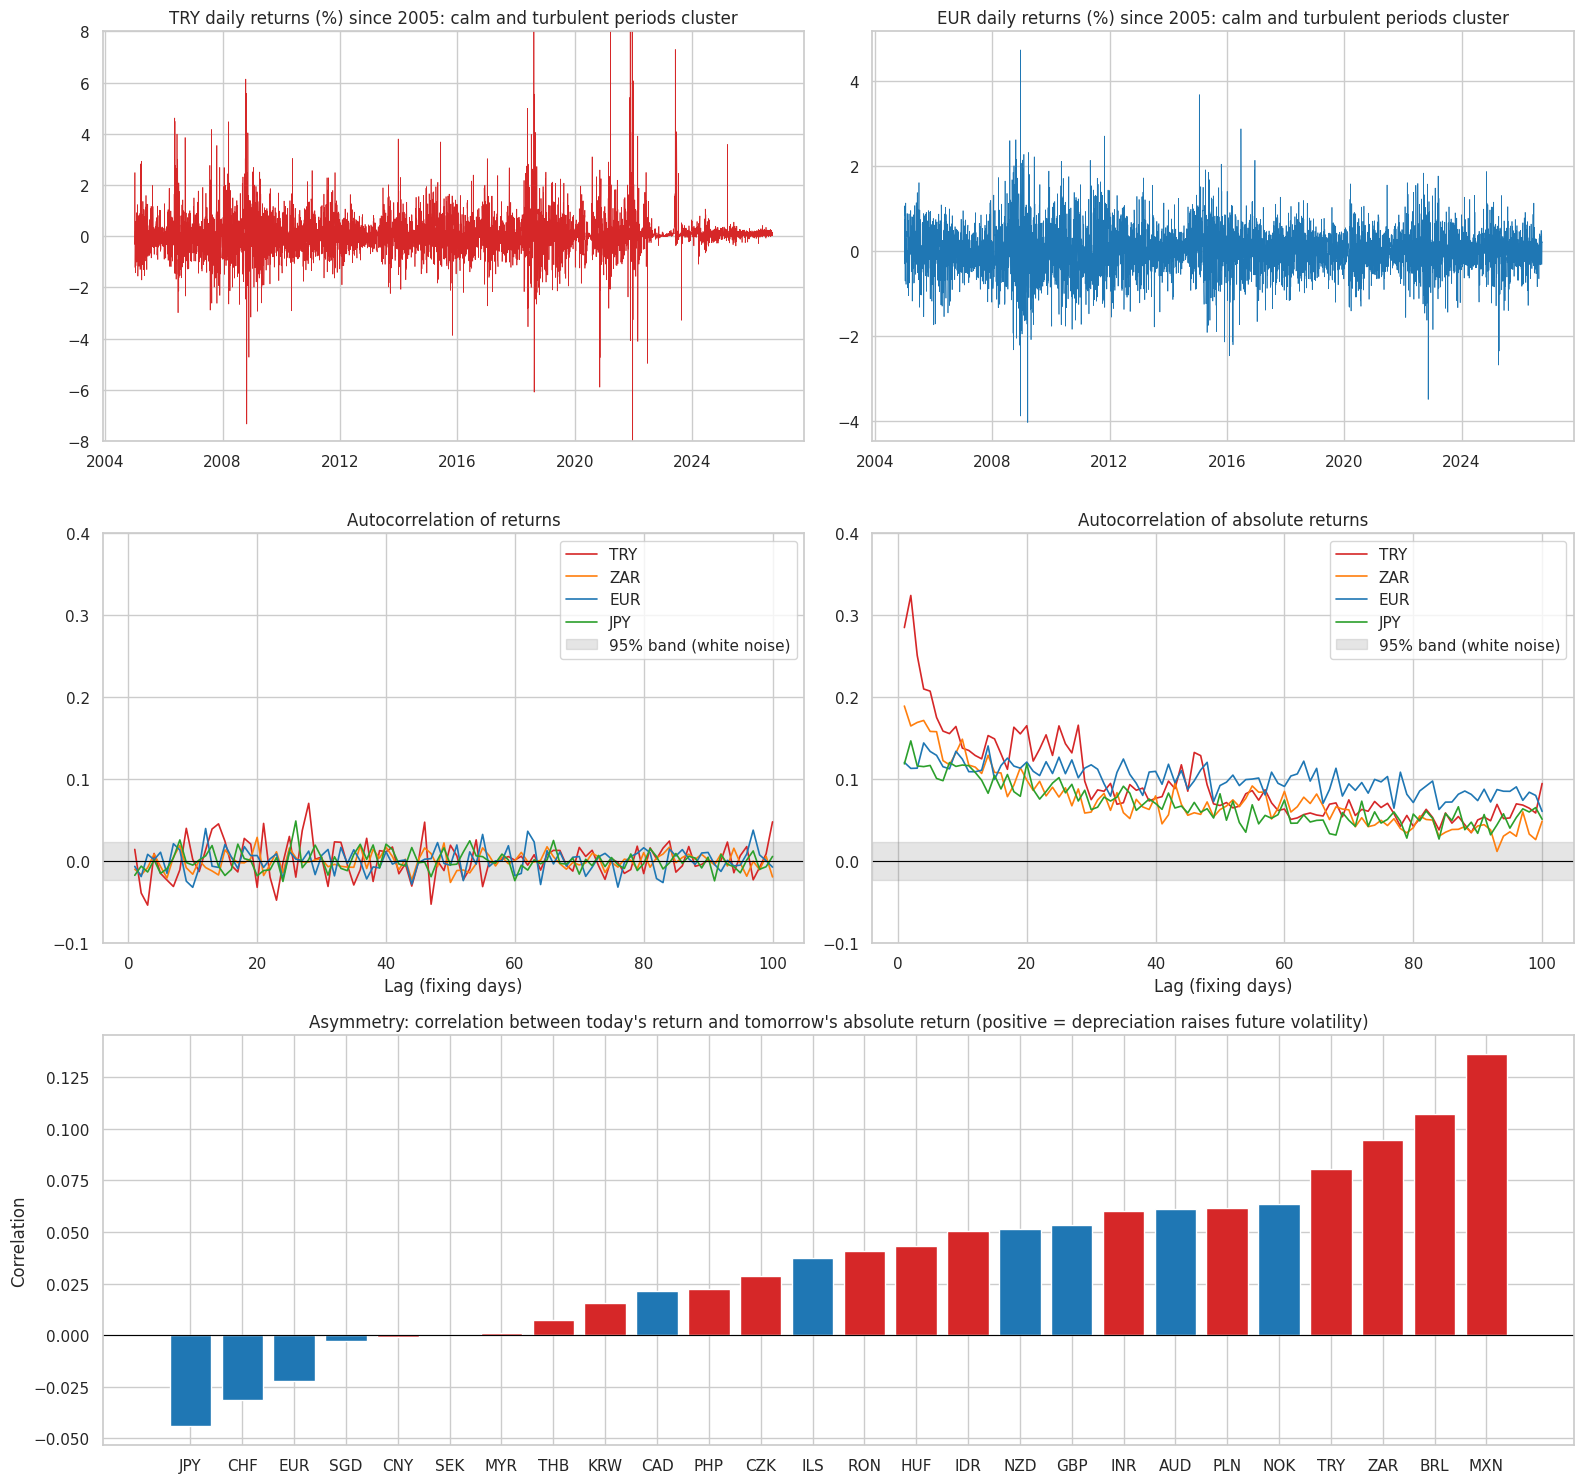

,group,acf1_returns,acf1_abs_returns,LB_returns_pvalue,LB_abs_stat,LB_abs_pvalue,ARCH_LM_stat,ARCH_LM_pvalue,asymmetry_corr
currency,,,,,,,,,
BRL,EM,-0.0457,0.3070,0.0053,2762.0583,0.0,1101.4520,0.0000,0.1071
MXN,EM,-0.0727,0.3484,0.0000,3365.8322,0.0,1615.2517,0.0000,0.1365
ZAR,EM,-0.0101,0.1891,0.2708,1699.2355,0.0,990.6261,0.0000,0.0947
TRY,EM,0.0141,0.2849,0.0000,3283.2650,0.0,22.0690,0.0005,0.0807
INR,EM,-0.0056,0.2390,0.0001,2235.5089,0.0,625.1528,0.0000,0.0600
IDR,EM,-0.0619,0.2893,0.0000,2853.5457,0.0,359.8408,0.0000,0.0507
KRW,EM,-0.0270,0.3299,0.0069,6035.0219,0.0,1291.3182,0.0000,0.0153
CNY,EM,-0.0423,0.3304,0.0000,2981.5160,0.0,326.7442,0.0000,-0.0008
THB,EM,0.0159,0.2462,0.0104,2202.5764,0.0,580.1325,0.0000,0.0071


In [11]:
LB_LAGS = 10
rows = []
for ccy in r.columns:
    x = r[ccy].dropna()
    lb_ret = acorr_ljungbox(x, lags=[LB_LAGS]).iloc[0]
    lb_abs = acorr_ljungbox(x.abs(), lags=[LB_LAGS]).iloc[0]
    arch_lm = het_arch(x, nlags=5)
    rows.append({
        "currency": ccy,
        "group": "EM" if ccy in EM else "DM",
        "acf1_returns": acf(x, nlags=1)[1],
        "acf1_abs_returns": acf(x.abs(), nlags=1)[1],
        "LB_returns_pvalue": lb_ret["lb_pvalue"],
        "LB_abs_stat": lb_abs["lb_stat"],
        "LB_abs_pvalue": lb_abs["lb_pvalue"],
        "ARCH_LM_stat": arch_lm[0],
        "ARCH_LM_pvalue": arch_lm[1],
        "asymmetry_corr": x.corr(x.abs().shift(-1)),
    })
facts = pd.DataFrame(rows).set_index("currency")

print(f"Currencies with significant return autocorrelation (5%)   : {(facts['LB_returns_pvalue'] < 0.05).sum()} / {len(facts)}")
print(f"Currencies with significant volatility clustering (5%)    : {(facts['LB_abs_pvalue'] < 0.05).sum()} / {len(facts)}")
print(f"Currencies where ARCH-LM rejects constant volatility (5%) : {(facts['ARCH_LM_pvalue'] < 0.05).sum()} / {len(facts)}")
print(f"Mean lag-1 autocorrelation: returns {facts['acf1_returns'].mean():.3f} | absolute returns {facts['acf1_abs_returns'].mean():.3f}")

MAX_LAG = 100
fig = plt.figure(figsize=(16, 15))
grid = fig.add_gridspec(3, 2)

for i, ccy in enumerate(["TRY", "EUR"]):
    ax = fig.add_subplot(grid[0, i])
    ax.plot(r[ccy].loc["2005":], lw=0.5, color="#d62728" if ccy in EM else "#1f77b4")
    if ccy == "TRY":
        ax.set_ylim(-8, 8)
    ax.set_title(f"{ccy} daily returns (%) since 2005: calm and turbulent periods cluster")

for i, (label, transform) in enumerate([("returns", lambda x: x), ("absolute returns", np.abs)]):
    ax = fig.add_subplot(grid[1, i])
    for ccy, color in zip(["TRY", "ZAR", "EUR", "JPY"], ["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"]):
        x = transform(r[ccy].dropna())
        ax.plot(range(1, MAX_LAG + 1), acf(x, nlags=MAX_LAG)[1:], color=color, lw=1.2, label=ccy)
    band = 1.96 / np.sqrt(r["EUR"].count())
    ax.axhspan(-band, band, color="grey", alpha=0.2, label="95% band (white noise)")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylim(-0.1, 0.4)
    ax.set_title(f"Autocorrelation of {label}")
    ax.set_xlabel("Lag (fixing days)")
    ax.legend()

ax = fig.add_subplot(grid[2, :])
ordered = facts["asymmetry_corr"].sort_values()
ax.bar(ordered.index, ordered.values, color=["#d62728" if c in EM else "#1f77b4" for c in ordered.index])
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Asymmetry: correlation between today's return and tomorrow's absolute return "
             "(positive = depreciation raises future volatility)")
ax.set_ylabel("Correlation")
plt.tight_layout()
plt.show()

facts.round(4)

## 9. Stationarity Tests

Most time-series models, GARCH and HMM included, assume the series they model is **stationary**: its mean and variance do not drift over time. We test this for both log prices and log returns using two complementary tests with *opposite* null hypotheses:

| Test | Null hypothesis | Rejection means |
|------|-----------------|-----------------|
| **ADF** (Augmented Dickey-Fuller) | The series has a unit root (non-stationary) | Stationary |
| **KPSS** | The series is stationary | Non-stationary |

Using both avoids relying on a single test's low power. A series is classified as:
- **stationary** if ADF rejects and KPSS does not,
- **non-stationary** if KPSS rejects and ADF does not,
- **inconclusive** if they disagree, which often signals a structural break rather than a simple random walk.

Log prices are tested with a constant and a trend, since currencies with persistent inflation differentials drift steadily; returns are tested with a constant only.

*A note from the previous step:* the Ljung-Box test found statistically significant return autocorrelation for 20 of 26 currencies, but the coefficients are tiny (between -0.07 and +0.04). With around 7,000 observations even negligible effects become statistically significant. We therefore keep a constant mean in the volatility models rather than adding autoregressive terms.

Verdict counts:
verdict    inconclusive  non-stationary  stationary
series                                             
log_price             1              25           0
return                3               0          23

Inconclusive cases:
currency    series  ADF_stat  ADF_pvalue  ADF_crit_5%  KPSS_stat  KPSS_pvalue  KPSS_crit_5%      verdict
     CNY    return   -11.252         0.0       -2.862      0.622        0.021         0.463 inconclusive
     PHP    return   -25.694         0.0       -2.862      0.536        0.034         0.463 inconclusive
     RON log_price    -5.067         0.0       -3.411      0.382        0.010         0.146 inconclusive
     RON    return   -17.514         0.0       -2.862      0.741        0.010         0.463 inconclusive


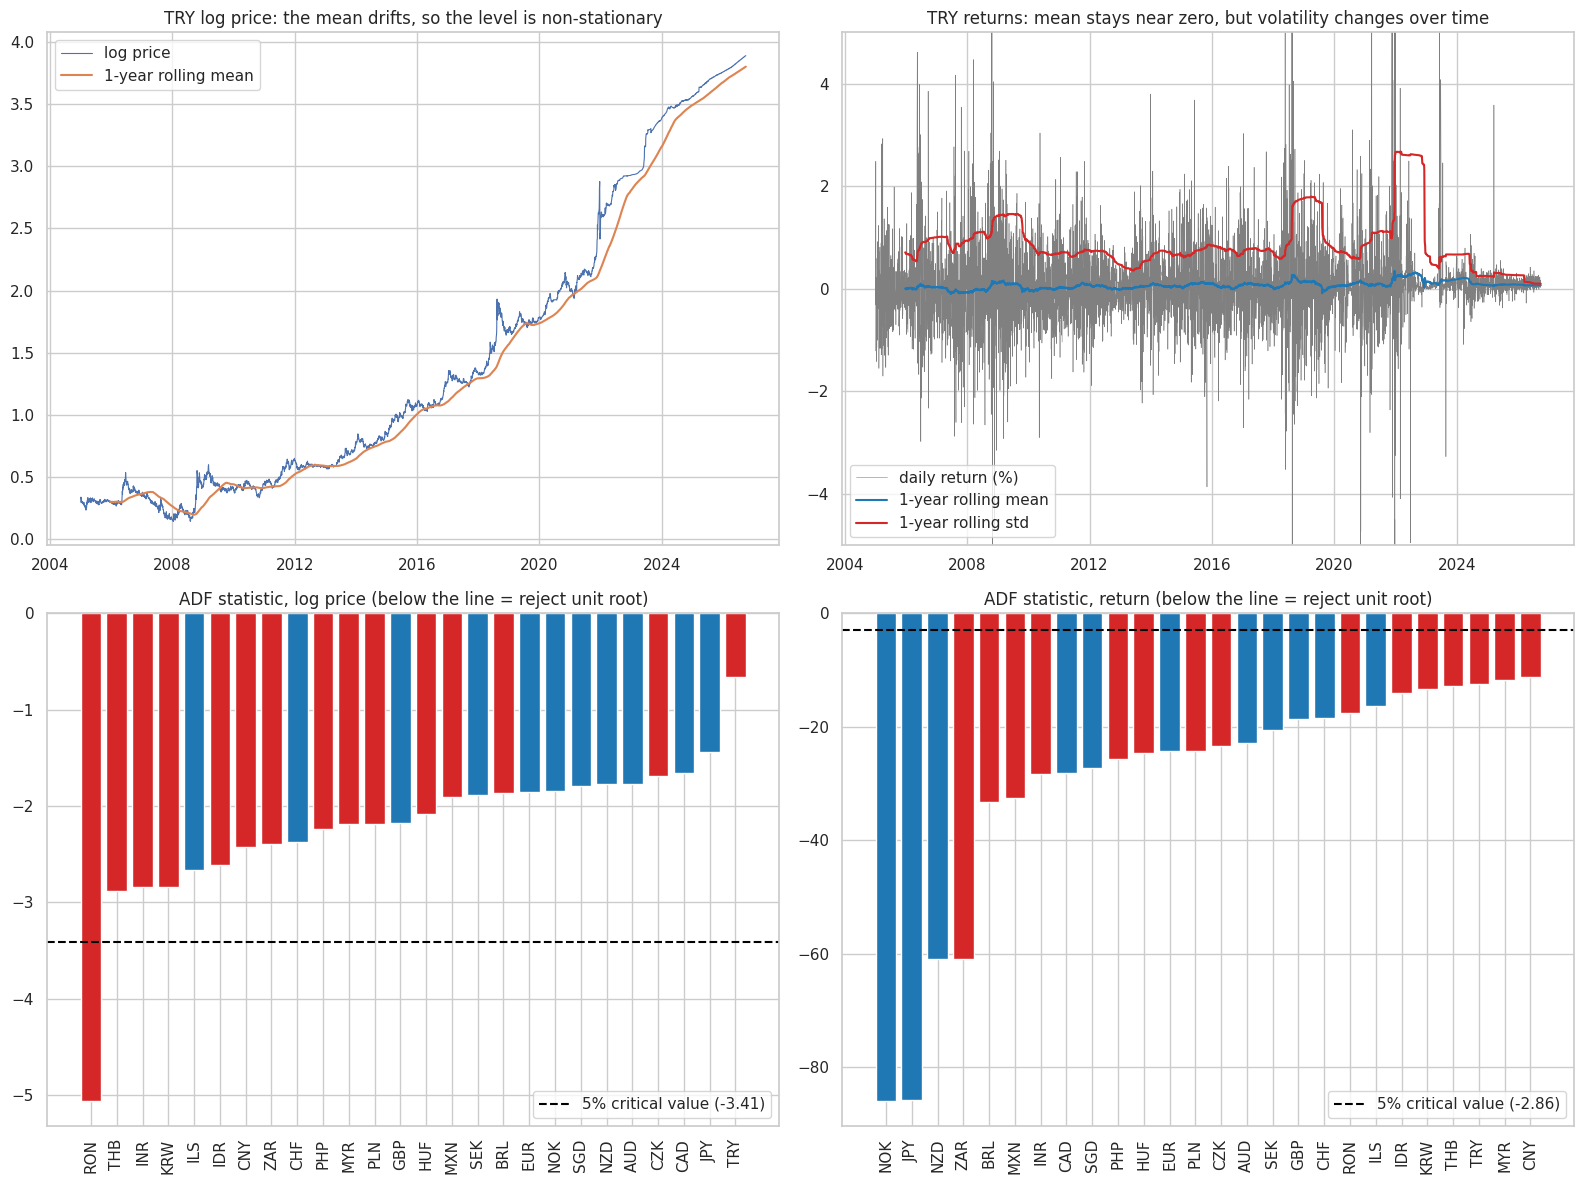

In [12]:
log_prices = np.log(prices)
rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for ccy in prices.columns:
        for series_name, series, regression in [("log_price", log_prices[ccy].dropna(), "ct"),
                                                ("return", r[ccy].dropna(), "c")]:
            adf = adfuller(series, regression=regression, autolag="AIC")
            kp = kpss(series, regression=regression, nlags="auto")
            rows.append({
                "currency": ccy, "series": series_name,
                "ADF_stat": adf[0], "ADF_pvalue": adf[1], "ADF_crit_5%": adf[4]["5%"],
                "KPSS_stat": kp[0], "KPSS_pvalue": kp[1], "KPSS_crit_5%": kp[3]["5%"],
            })

stationarity = pd.DataFrame(rows)
adf_stationary = stationarity["ADF_pvalue"] < 0.05
kpss_stationary = stationarity["KPSS_pvalue"] >= 0.05
stationarity["verdict"] = np.select(
    [adf_stationary & kpss_stationary, ~adf_stationary & ~kpss_stationary],
    ["stationary", "non-stationary"], default="inconclusive")

print("Verdict counts:")
print(pd.crosstab(stationarity["series"], stationarity["verdict"]))
print("\nInconclusive cases:")
print(stationarity[stationarity["verdict"] == "inconclusive"].round(3).to_string(index=False))

WINDOW = 252
fig = plt.figure(figsize=(16, 12))
grid = fig.add_gridspec(2, 2)

ax = fig.add_subplot(grid[0, 0])
try_log_price = log_prices["TRY"].loc["2005":]
ax.plot(try_log_price, lw=0.8, label="log price")
ax.plot(try_log_price.rolling(WINDOW).mean(), label="1-year rolling mean")
ax.set_title("TRY log price: the mean drifts, so the level is non-stationary")
ax.legend()

ax = fig.add_subplot(grid[0, 1])
try_returns = r["TRY"].loc["2005":]
ax.plot(try_returns, lw=0.4, color="grey", label="daily return (%)")
ax.plot(try_returns.rolling(WINDOW).mean(), color="#1f77b4", label="1-year rolling mean")
ax.plot(try_returns.rolling(WINDOW).std(), color="#d62728", label="1-year rolling std")
ax.set_ylim(-5, 5)
ax.set_title("TRY returns: mean stays near zero, but volatility changes over time")
ax.legend()

for i, series_name in enumerate(["log_price", "return"]):
    ax = fig.add_subplot(grid[1, i])
    subset = stationarity[stationarity["series"] == series_name].set_index("currency")["ADF_stat"].sort_values()
    ax.bar(subset.index, subset.values, color=["#d62728" if c in EM else "#1f77b4" for c in subset.index])
    critical = stationarity.loc[stationarity["series"] == series_name, "ADF_crit_5%"].iloc[0]
    ax.axhline(critical, color="black", ls="--", label=f"5% critical value ({critical:.2f})")
    ax.set_title(f"ADF statistic, {series_name.replace('_', ' ')} (below the line = reject unit root)")
    ax.tick_params(axis="x", rotation=90)
    ax.legend()
plt.tight_layout()
plt.show()

## 10. GARCH Volatility Modeling: Model Selection on TRY

The previous steps established that returns are barely predictable but their volatility clusters, reacts asymmetrically and has fat tails. GARCH-family models capture exactly these features by letting today's variance depend on yesterday's shock and yesterday's variance.

We estimate three volatility specifications:
- **GARCH(1,1)**: symmetric; a shock of a given size raises volatility equally whatever its sign.
- **GJR-GARCH(1,1,1)**: adds an extra term for negative shocks, so the sign of a shock matters. Note that under our quoting convention a negative shock is a TRY *appreciation*, while Section 8 showed that for TRY it is depreciations that raise future volatility.
- **EGARCH(1,1,1)**: models the *log* of variance, which keeps variance positive without parameter constraints and allows an asymmetric response in either direction.

Each is combined with three error distributions: **Normal**, **Student-t** (fat tails) and **Skewed Student-t** (fat and asymmetric tails), giving 9 candidates. Models are compared by **BIC**, which penalises extra parameters more heavily than AIC.

**Sample:** TRY from 3 January 2005 onwards (5,562 returns). The February 2001 float, a single +53% day that ended a crawling peg, belongs to a different exchange-rate regime and would dominate the estimation.

**Persistence** measures how slowly a volatility shock fades: alpha + beta (+ gamma/2 for GJR) for GARCH-type models, beta for EGARCH. Values close to 1 mean shocks are extremely long-lived.

*Note:* two specifications may print a convergence warning during estimation; they are flagged in the `converged` column of the comparison table and are not selected.

/tmp/ipykernel_690/1483590537.py:22: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res = arch_model(y, mean="Constant", dist=dist, **spec).fit(disp="off")


Selected model: EGARCH with Skewed-t errors

                           Constant Mean - EGARCH Model Results                          
Dep. Variable:                               TRY   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                EGARCH   Log-Likelihood:               -4566.17
Distribution:      Standardized Skew Student's t   AIC:                           9146.34
Method:                       Maximum Likelihood   BIC:                           9192.71
                                                   No. Observations:                 5566
Date:                           Wed, Sep 30 2026   Df Residuals:                     5565
Time:                                   08:55:58   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Co

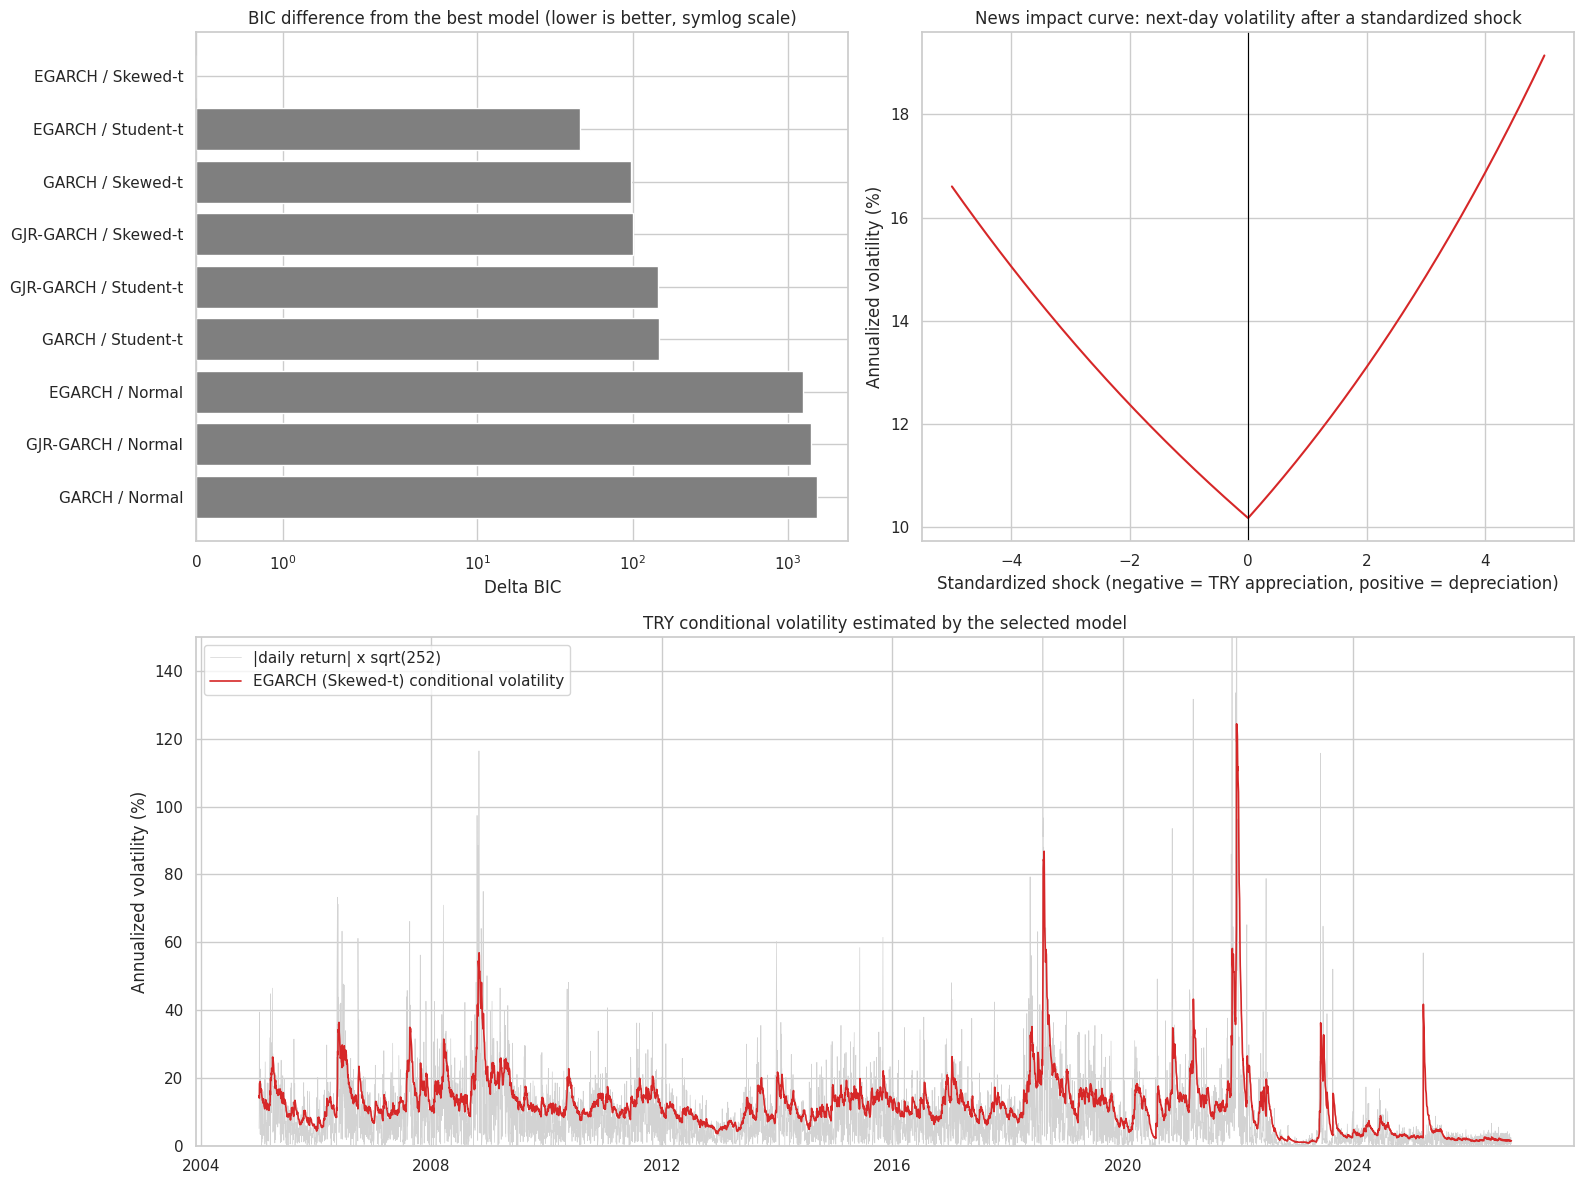

In [13]:
try:
    from arch import arch_model
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "arch"], check=True)
    from arch import arch_model

GARCH_START = "2005-01-03"
y = r["TRY"].loc[GARCH_START:].dropna()

SPECS = {
    "GARCH": dict(vol="GARCH", p=1, o=0, q=1),
    "GJR-GARCH": dict(vol="GARCH", p=1, o=1, q=1),
    "EGARCH": dict(vol="EGARCH", p=1, o=1, q=1),
}
DISTRIBUTIONS = {"Normal": "normal", "Student-t": "t", "Skewed-t": "skewt"}

fits, rows = {}, []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for spec_name, spec in SPECS.items():
        for dist_name, dist in DISTRIBUTIONS.items():
            res = arch_model(y, mean="Constant", dist=dist, **spec).fit(disp="off")
            fits[(spec_name, dist_name)] = res
            p = res.params
            if spec_name == "EGARCH":
                persistence = p["beta[1]"]
            else:
                persistence = p["alpha[1]"] + p["beta[1]"] + 0.5 * p.get("gamma[1]", 0)
            rows.append({
                "model": spec_name, "distribution": dist_name,
                "log_likelihood": res.loglikelihood, "AIC": res.aic, "BIC": res.bic,
                "n_params": len(p), "persistence": persistence,
                "converged": res.convergence_flag == 0,
            })

comparison = pd.DataFrame(rows).sort_values("BIC").reset_index(drop=True)
comparison["delta_BIC"] = comparison["BIC"] - comparison["BIC"].min()
best_key = tuple(comparison.loc[0, ["model", "distribution"]])
best_fit = fits[best_key]
print(f"Selected model: {best_key[0]} with {best_key[1]} errors\n")
print(best_fit.summary())

cond_vol = best_fit.conditional_volatility * np.sqrt(252)

fig = plt.figure(figsize=(16, 12))
grid = fig.add_gridspec(2, 2)

ax = fig.add_subplot(grid[0, 0])
plot_df = comparison.assign(label=comparison["model"] + " / " + comparison["distribution"]) \
                    .sort_values("delta_BIC", ascending=False)
ax.barh(plot_df["label"], plot_df["delta_BIC"],
        color=["#2ca02c" if d == 0 else "#7f7f7f" for d in plot_df["delta_BIC"]])
ax.set_xscale("symlog")
ax.set_title("BIC difference from the best model (lower is better, symlog scale)")
ax.set_xlabel("Delta BIC")

# News impact curve: how next-day volatility responds to a shock of each size and sign
ax = fig.add_subplot(grid[0, 1])
p = best_fit.params
z = np.linspace(-5, 5, 201)
ln_sigma2_typical = np.log(np.median(best_fit.conditional_volatility ** 2))
next_var = np.exp(p["omega"] + p["alpha[1]"] * (np.abs(z) - np.sqrt(2 / np.pi))
                  + p["gamma[1]"] * z + p["beta[1]"] * ln_sigma2_typical)
ax.plot(z, np.sqrt(next_var * 252), color="#d62728")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("News impact curve: next-day volatility after a standardized shock")
ax.set_xlabel("Standardized shock (negative = TRY appreciation, positive = depreciation)")
ax.set_ylabel("Annualized volatility (%)")

ax = fig.add_subplot(grid[1, :])
ax.plot(y.index, np.abs(y) * np.sqrt(252), color="lightgrey", lw=0.5, label="|daily return| x sqrt(252)")
ax.plot(cond_vol, color="#d62728", lw=1.2, label=f"{best_key[0]} ({best_key[1]}) conditional volatility")
ax.set_ylim(0, 150)
ax.set_ylabel("Annualized volatility (%)")
ax.set_title("TRY conditional volatility estimated by the selected model")
ax.legend()
plt.tight_layout()
plt.show()

comparison.round(3);

## 11. Model Diagnostics and Out-of-Sample VaR Backtest

A good volatility model should leave nothing predictable behind. If the model is correctly specified, its **standardized residuals** (return minus mean, divided by the model's conditional volatility) should show no remaining volatility clustering and should follow the assumed error distribution.

**In-sample diagnostics:**
- Ljung-Box tests on absolute and squared standardized residuals, plus the ARCH-LM test: volatility clustering should disappear.
- Q-Q plot against the fitted skewed Student-t: points should lie on the diagonal.

**Out-of-sample Value-at-Risk backtest.** The real test of a risk model is how it performs on data it has never seen. We estimate the model on 2005-2019 only, keep the parameters fixed, and produce one-day-ahead forecasts for every day from January 2020 onwards: 1,724 days that include the pandemic, the 2021 lira crisis and the 2023 policy shift.

The 99% VaR is the depreciation that should be exceeded on only 1% of days. We compare three approaches:
- **EGARCH / Skewed-t**: the selected model.
- **GARCH / Normal**: the textbook benchmark.
- **Historical simulation**: the empirical quantile of the last 250 days, a model-free approach common in banks.

Two formal tests:
- **Kupiec (unconditional coverage)**: is the breach frequency consistent with the target (1% or 5%)?
- **Christoffersen (independence)**: are breaches spread out, or do they cluster? A model whose breaches arrive in bunches reacts too slowly to changing risk.

A good model passes both (p-value above 0.05).

In-sample diagnostics:
                   raw returns  standardized residuals
LB_abs_stat          4394.5587                 29.3471
LB_abs_pvalue           0.0000                  0.0011
LB_squared_stat       296.7571                  0.7281
LB_squared_pvalue       0.0000                  1.0000
ARCH_LM_pvalue          0.0000                  0.9998
skew                   -4.4016                  1.5550
excess_kurtosis       195.3117                 56.5240

Largest standardized residuals (shocks the model did not anticipate):
date
2025-03-19    23.11
2023-08-24    17.29
2022-06-27     9.12
2020-07-28     8.81
2023-06-07     8.13


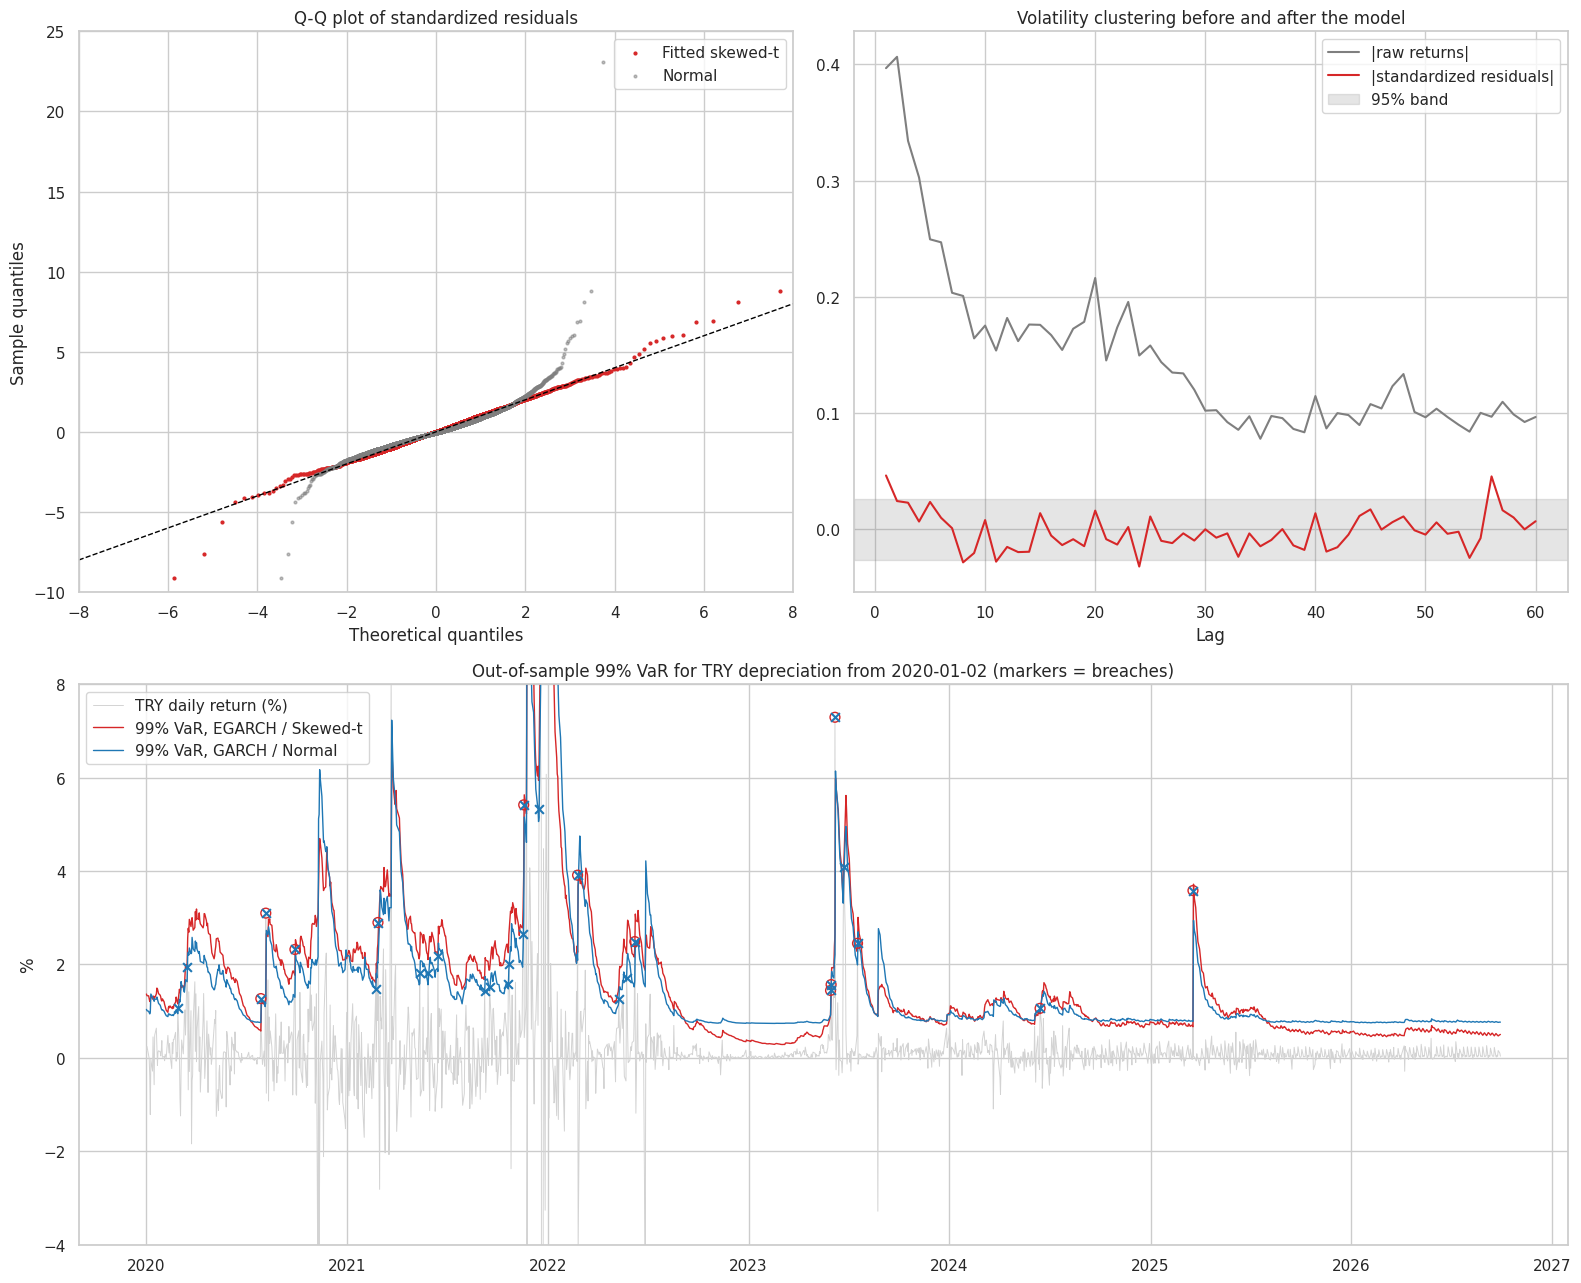

,model,VaR_level,expected_breach_%,observed_breach_%,breaches,kupiec_pvalue,christoffersen_pvalue,avg_VaR_%,passes_both
0,EGARCH / Skewed-t,0.95,5.0,3.0671,53,0.0001,0.0010,1.0034,False
1,EGARCH / Skewed-t,0.99,1.0,0.9259,16,0.7540,0.1373,1.6253,True
2,GARCH / Normal,0.95,5.0,2.7778,48,0.0000,0.0003,1.1607,False
3,GARCH / Normal,0.99,1.0,1.7940,31,0.0028,0.0018,1.6342,False
4,Historical 250-day,0.95,5.0,5.1505,89,0.7752,0.0000,1.1050,False
5,Historical 250-day,0.99,1.0,1.2731,22,0.2736,0.0000,2.2573,False


In [14]:
# In-sample diagnostics: raw returns vs standardized residuals
std_resid = (best_fit.resid / best_fit.conditional_volatility).dropna()
diagnostics = {}
for name, series in [("raw returns", y - y.mean()), ("standardized residuals", std_resid)]:
    s = series / series.std()
    diagnostics[name] = {
        "LB_abs_stat": acorr_ljungbox(s.abs(), lags=[10]).iloc[0]["lb_stat"],
        "LB_abs_pvalue": acorr_ljungbox(s.abs(), lags=[10]).iloc[0]["lb_pvalue"],
        "LB_squared_stat": acorr_ljungbox(s ** 2, lags=[10]).iloc[0]["lb_stat"],
        "LB_squared_pvalue": acorr_ljungbox(s ** 2, lags=[10]).iloc[0]["lb_pvalue"],
        "ARCH_LM_pvalue": het_arch(s, nlags=5)[1],
        "skew": s.skew(),
        "excess_kurtosis": s.kurt(),
    }
print("In-sample diagnostics:")
print(pd.DataFrame(diagnostics).round(4))
print("\nLargest standardized residuals (shocks the model did not anticipate):")
print(std_resid.abs().nlargest(5).round(2).to_string())

# Out-of-sample one-day-ahead VaR with parameters estimated before OOS_START
OOS_START = "2020-01-02"
split = y.index.get_loc(y.loc[OOS_START:].index[0])
realized = y.iloc[split:]

VAR_MODELS = {
    "EGARCH / Skewed-t": dict(vol="EGARCH", p=1, o=1, q=1, dist="skewt"),
    "GARCH / Normal": dict(vol="GARCH", p=1, o=0, q=1, dist="normal"),
}
VAR_LEVELS = [0.95, 0.99]
var_forecasts = {}

for name, spec in VAR_MODELS.items():
    model = arch_model(y, mean="Constant", **spec)
    res = model.fit(last_obs=y.index[split], disp="off")
    forecast = res.forecast(start=y.index[split - 1], horizon=1, reindex=False)
    mu = forecast.mean.iloc[:len(realized), 0].values
    sigma = np.sqrt(forecast.variance.iloc[:len(realized), 0].values)
    dist_param_names = model.distribution.parameter_names()
    dist_params = res.params[dist_param_names].values if dist_param_names else None
    for level in VAR_LEVELS:
        quantile = model.distribution.ppf(level, dist_params)
        var_forecasts[(name, level)] = pd.Series(mu + sigma * quantile, index=realized.index)

for level in VAR_LEVELS:
    var_forecasts[("Historical 250-day", level)] = y.rolling(250).quantile(level).shift(1).iloc[split:]

def kupiec_test(hits, p):
    n, x = len(hits), hits.sum()
    p_hat = x / n
    if x == 0:
        lr = -2 * n * np.log(1 - p)
    else:
        lr = -2 * ((n - x) * np.log(1 - p) + x * np.log(p) - (n - x) * np.log(1 - p_hat) - x * np.log(p_hat))
    return stats.chi2.sf(lr, 1)

def christoffersen_test(hits):
    h = hits.astype(int).values
    prev, curr = h[:-1], h[1:]
    n00, n01 = ((prev == 0) & (curr == 0)).sum(), ((prev == 0) & (curr == 1)).sum()
    n10, n11 = ((prev == 1) & (curr == 0)).sum(), ((prev == 1) & (curr == 1)).sum()
    p01 = n01 / (n00 + n01)
    p11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    p = (n01 + n11) / (n00 + n01 + n10 + n11)
    loglik = lambda k, q: k * np.log(q) if q > 0 else 0
    ll_null = loglik(n00 + n10, 1 - p) + loglik(n01 + n11, p)
    ll_alt = loglik(n00, 1 - p01) + loglik(n01, p01) + loglik(n10, 1 - p11) + loglik(n11, p11)
    return stats.chi2.sf(-2 * (ll_null - ll_alt), 1)

backtest_rows = []
for (name, level), var_series in var_forecasts.items():
    hits = realized > var_series
    backtest_rows.append({
        "model": name,
        "VaR_level": level,
        "expected_breach_%": (1 - level) * 100,
        "observed_breach_%": hits.mean() * 100,
        "breaches": int(hits.sum()),
        "kupiec_pvalue": kupiec_test(hits, 1 - level),
        "christoffersen_pvalue": christoffersen_test(hits),
        "avg_VaR_%": var_series.mean(),
    })
backtest = pd.DataFrame(backtest_rows)
backtest["passes_both"] = (backtest["kupiec_pvalue"] > 0.05) & (backtest["christoffersen_pvalue"] > 0.05)

fig = plt.figure(figsize=(16, 13))
grid = fig.add_gridspec(2, 2)

ax = fig.add_subplot(grid[0, 0])
sorted_resid = np.sort(std_resid.values)
positions = (np.arange(1, len(sorted_resid) + 1) - 0.5) / len(sorted_resid)
dist_params_best = best_fit.params[best_fit.model.distribution.parameter_names()].values
ax.scatter(best_fit.model.distribution.ppf(positions, dist_params_best), sorted_resid,
           s=4, color="#d62728", label="Fitted skewed-t")
ax.scatter(stats.norm.ppf(positions), sorted_resid, s=4, color="#7f7f7f", alpha=0.5, label="Normal")
ax.plot([-8, 8], [-8, 8], color="black", ls="--", lw=1)
ax.set_xlim(-8, 8)
ax.set_ylim(-10, 25)
ax.set_title("Q-Q plot of standardized residuals")
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.legend()

ax = fig.add_subplot(grid[0, 1])
LAGS = 60
ax.plot(range(1, LAGS + 1), acf(np.abs(y - y.mean()), nlags=LAGS)[1:], color="#7f7f7f", label="|raw returns|")
ax.plot(range(1, LAGS + 1), acf(std_resid.abs(), nlags=LAGS)[1:], color="#d62728", label="|standardized residuals|")
band = 1.96 / np.sqrt(len(std_resid))
ax.axhspan(-band, band, color="grey", alpha=0.2, label="95% band")
ax.set_title("Volatility clustering before and after the model")
ax.set_xlabel("Lag")
ax.legend()

ax = fig.add_subplot(grid[1, :])
ax.plot(realized, color="lightgrey", lw=0.7, label="TRY daily return (%)")
for name, color, marker in [("EGARCH / Skewed-t", "#d62728", "o"), ("GARCH / Normal", "#1f77b4", "x")]:
    var_series = var_forecasts[(name, 0.99)]
    ax.plot(var_series, color=color, lw=1, label=f"99% VaR, {name}")
    breaches = realized[realized > var_series]
    if marker == "o":
        ax.scatter(breaches.index, breaches.values, s=50, marker="o", facecolors="none", edgecolors=color, zorder=3)
    else:
        ax.scatter(breaches.index, breaches.values, s=40, marker="x", color=color, zorder=4)
ax.set_ylim(-4, 8)
ax.set_ylabel("%")
ax.set_title(f"Out-of-sample 99% VaR for TRY depreciation from {OOS_START} (markers = breaches)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

backtest.round(4)

## 12. Regime Detection with a Hidden Markov Model

GARCH treats volatility as a smooth process, and the diagnostics exposed its blind spot: persistence close to 1 and huge unexpected shocks when a crisis hits a calm period. Both are symptoms of **regime switching**. The exchange rate does not drift smoothly between calm and turbulent; it jumps between distinct states with very different behaviour.

A **Gaussian Hidden Markov Model** formalises this idea:
- There are *K* hidden states (regimes). In each state, daily returns follow a normal distribution with its own mean and volatility.
- The state changes from day to day according to a **transition matrix**: the probability of moving from regime *i* today to regime *j* tomorrow.
- The model is estimated by maximum likelihood (Baum-Welch algorithm). Because the likelihood has many local optima, each specification is estimated from 10 random starting points and the best one is kept.

**Choosing the number of regimes.** BIC alone is not enough here: with fat-tailed returns, a Gaussian HMM can "improve" its fit by dedicating a whole state to a single extreme day. We therefore select the lowest-BIC model among those where **every regime covers at least 1% of days and has an expected duration of at least 5 days**. Expected duration of regime *i* is 1 / (1 - p_ii), where p_ii is the probability of staying in it.

States are ordered by volatility, from lowest to highest. We report two outputs:
- the **Viterbi path**: the single most likely sequence of regimes,
- the **posterior probabilities**: for each day, the probability of being in each regime given all the data.

Model selection:
 n_states  log_likelihood  n_params      BIC  min_occupancy_%  min_duration_days  valid
        2        -5895.78         7 11851.92            13.89               6.79   True
        3        -4859.36        14  9839.46             7.28               6.51   True
        4        -4780.62        23  9759.61             0.02               1.00  False
        5        -4608.21        34  9509.64             0.02               1.00  False

Selected: 3 regimes

Transition matrix:
            Controlled  Normal  Crisis
Controlled      0.9793  0.0163  0.0044
Normal          0.0048  0.9788  0.0165
Crisis          0.0078  0.1459  0.8463


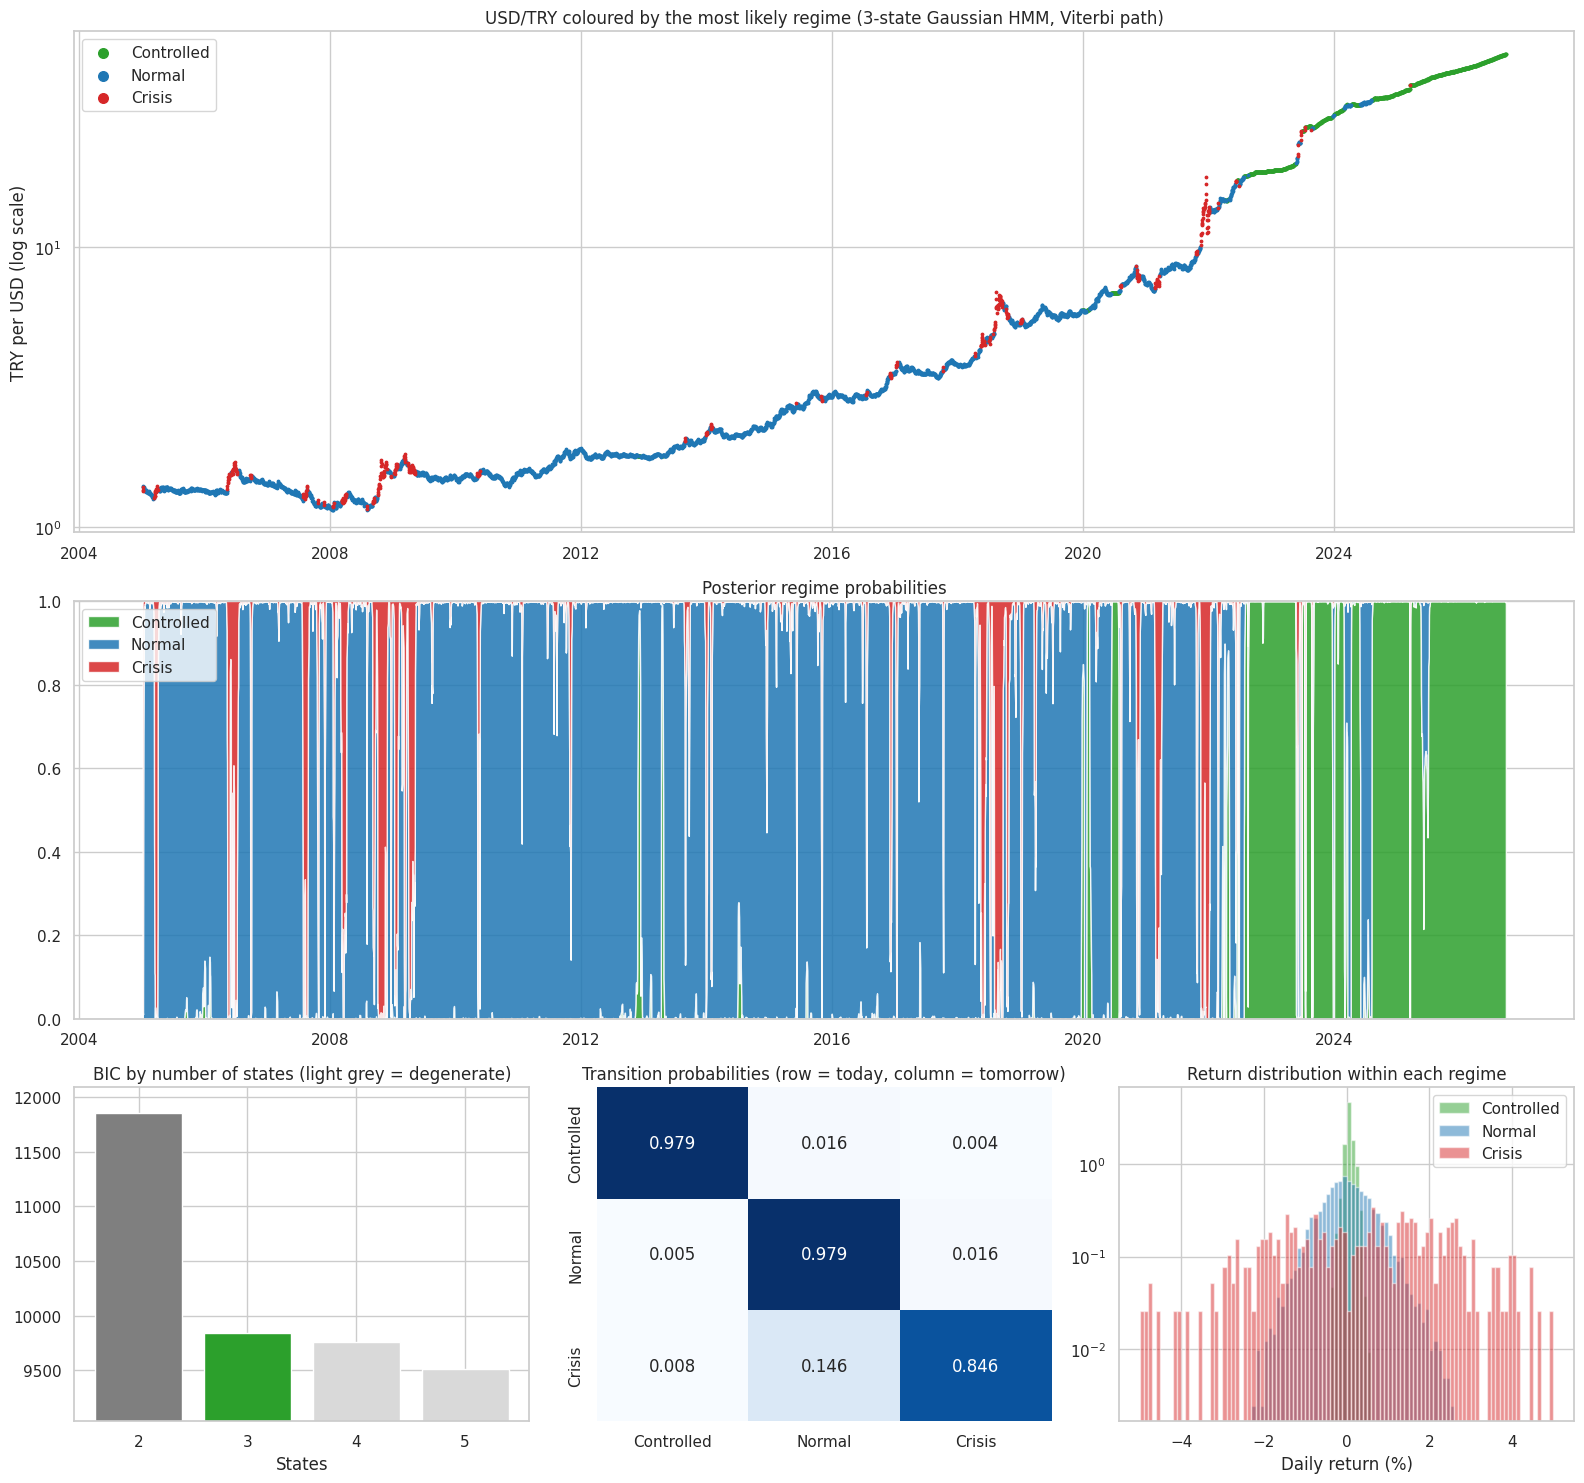

,ann_mean_%,ann_vol_%,occupancy_%,expected_duration_days,episodes,longest_episode_days
Controlled,15.72,1.86,19.19,48.35,18,390
Normal,6.10,10.37,73.54,47.10,57,650
Crisis,105.05,44.36,7.28,6.51,48,39


In [15]:
try:
    from hmmlearn.hmm import GaussianHMM
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "hmmlearn"], check=True)
    from hmmlearn.hmm import GaussianHMM

HMM_START = "2005-01-03"
y_hmm = r["TRY"].loc[HMM_START:].dropna()
X = y_hmm.values.reshape(-1, 1)

N_RESTARTS = 10
MIN_OCCUPANCY = 0.01
MIN_DURATION = 5

def fit_hmm(n_states):
    best_model, best_ll = None, -np.inf
    for seed in range(N_RESTARTS):
        model = GaussianHMM(n_components=n_states, covariance_type="full",
                            n_iter=500, tol=1e-5, random_state=seed)
        model.fit(X)
        ll = model.score(X)
        if ll > best_ll:
            best_model, best_ll = model, ll
    order = np.argsort(best_model.covars_.ravel())
    return best_model, best_ll, order

hmm_fits, rows = {}, []
for n_states in range(2, 6):
    model, ll, order = fit_hmm(n_states)
    states = np.argsort(order)[model.predict(X)]
    occupancy = np.bincount(states, minlength=n_states) / len(states)
    duration = 1 / (1 - np.diag(model.transmat_)[order])
    n_params = (n_states - 1) + n_states * (n_states - 1) + 2 * n_states
    hmm_fits[n_states] = (model, order)
    rows.append({
        "n_states": n_states, "log_likelihood": ll, "n_params": n_params,
        "BIC": -2 * ll + n_params * np.log(len(X)),
        "min_occupancy_%": occupancy.min() * 100,
        "min_duration_days": duration.min(),
        "valid": (occupancy.min() >= MIN_OCCUPANCY) and (duration.min() >= MIN_DURATION),
    })

hmm_selection = pd.DataFrame(rows)
N_STATES = int(hmm_selection[hmm_selection["valid"]].sort_values("BIC").iloc[0]["n_states"])
print("Model selection:")
print(hmm_selection.round(2).to_string(index=False))
print(f"\nSelected: {N_STATES} regimes")

hmm_model, order = hmm_fits[N_STATES]
rank = np.argsort(order)
STATE_NAMES = {2: ["Calm", "Turbulent"], 3: ["Controlled", "Normal", "Crisis"]}.get(
    N_STATES, [f"State {i}" for i in range(N_STATES)])
STATE_COLORS = ["#2ca02c", "#1f77b4", "#d62728", "#9467bd", "#8c564b"][:N_STATES]

regime = pd.Series(rank[hmm_model.predict(X)], index=y_hmm.index)
posterior = pd.DataFrame(hmm_model.predict_proba(X)[:, order], index=y_hmm.index, columns=STATE_NAMES)

episode_id = (regime != regime.shift()).cumsum()
episodes = pd.DataFrame({"state": regime.groupby(episode_id).first(),
                         "length": regime.groupby(episode_id).size()})

state_summary = pd.DataFrame({
    "ann_mean_%": hmm_model.means_.ravel()[order] * 252,
    "ann_vol_%": np.sqrt(hmm_model.covars_.ravel()[order] * 252),
    "occupancy_%": np.bincount(regime, minlength=N_STATES) / len(regime) * 100,
    "expected_duration_days": 1 / (1 - np.diag(hmm_model.transmat_)[order]),
    "episodes": episodes["state"].value_counts().reindex(range(N_STATES), fill_value=0).values,
    "longest_episode_days": episodes.groupby("state")["length"].max().reindex(range(N_STATES), fill_value=0).values,
}, index=STATE_NAMES)
transition = pd.DataFrame(hmm_model.transmat_[np.ix_(order, order)], index=STATE_NAMES, columns=STATE_NAMES)
print("\nTransition matrix:")
print(transition.round(4))

fig = plt.figure(figsize=(16, 15))
grid = fig.add_gridspec(3, 3, height_ratios=[1.2, 1, 0.8])

ax = fig.add_subplot(grid[0, :])
try_price = prices["TRY"].loc[y_hmm.index]
for i, name in enumerate(STATE_NAMES):
    mask = regime == i
    ax.scatter(try_price.index[mask], try_price[mask], s=3, color=STATE_COLORS[i], label=name)
ax.set_yscale("log")
ax.set_ylabel("TRY per USD (log scale)")
ax.set_title(f"USD/TRY coloured by the most likely regime ({N_STATES}-state Gaussian HMM, Viterbi path)")
ax.legend(markerscale=4)

ax = fig.add_subplot(grid[1, :])
ax.stackplot(posterior.index, posterior.T.values, colors=STATE_COLORS, labels=STATE_NAMES, alpha=0.85)
ax.set_ylim(0, 1)
ax.set_title("Posterior regime probabilities")
ax.legend(loc="upper left")

ax = fig.add_subplot(grid[2, 0])
bar_colors = ["#2ca02c" if n == N_STATES else ("#7f7f7f" if v else "#d9d9d9")
              for n, v in zip(hmm_selection["n_states"], hmm_selection["valid"])]
ax.bar(hmm_selection["n_states"].astype(str), hmm_selection["BIC"], color=bar_colors)
ax.set_ylim(hmm_selection["BIC"].min() * 0.95, hmm_selection["BIC"].max() * 1.02)
ax.set_title("BIC by number of states (light grey = degenerate)")
ax.set_xlabel("States")

ax = fig.add_subplot(grid[2, 1])
sns.heatmap(transition, annot=True, fmt=".3f", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Transition probabilities (row = today, column = tomorrow)")

ax = fig.add_subplot(grid[2, 2])
for i, name in enumerate(STATE_NAMES):
    ax.hist(y_hmm[regime == i], bins=100, range=(-5, 5), density=True,
            alpha=0.5, color=STATE_COLORS[i], label=name)
ax.set_yscale("log")
ax.set_title("Return distribution within each regime")
ax.set_xlabel("Daily return (%)")
ax.legend()
plt.tight_layout()
plt.show()

state_summary.round(2)

## 13. Matching Regimes to Historical Crises

A regime model is only convincing if its regimes correspond to something real. Here we check whether the **Crisis** regime lines up with known episodes of Turkish and global financial stress, even though the model never saw a calendar of events.

**Crisis windows.** The Viterbi path often splits one crisis into several fragments separated by a day or two classified as Normal. We merge crisis days separated by at most 10 fixing days into a single window, and for each window report its length, the total move in TRY, the largest single-day move and the peak GARCH volatility.

**Event matching.** We then list well-known market events and check whether each falls inside a detected window. The event list covers both **domestic** shocks (policy changes, central bank decisions, political events) and **global** ones (the 2008 financial crisis, the euro debt crisis, the invasion of Ukraine).

**HMM vs GARCH.** Finally we compare the two models: how GARCH conditional volatility is distributed within each HMM regime, and how much of the highest-volatility GARCH days fall inside the Crisis regime.

Crisis windows detected: 43
Events matched: 23 / 23
Unlabelled windows: 20 | median length 4 days, median |TRY move| 1.9%
Labelled windows  : 23 | median length 10 days, median |TRY move| 5.6%

GARCH conditional volatility by HMM regime (annualized %):
             count  mean   std  min   25%   50%   75%    max
regime                                                      
Controlled  1068.0   3.8   4.0  0.8   1.8   2.6   4.3   41.7
Normal      4093.0  12.5   5.2  2.2   9.3  11.8  14.7   72.7
Crisis       405.0  29.2  19.9  2.4  18.6  23.1  32.5  124.4

Share of the top-5% GARCH volatility days falling in each regime:
Controlled    0.032
Normal        0.362
Crisis        0.606


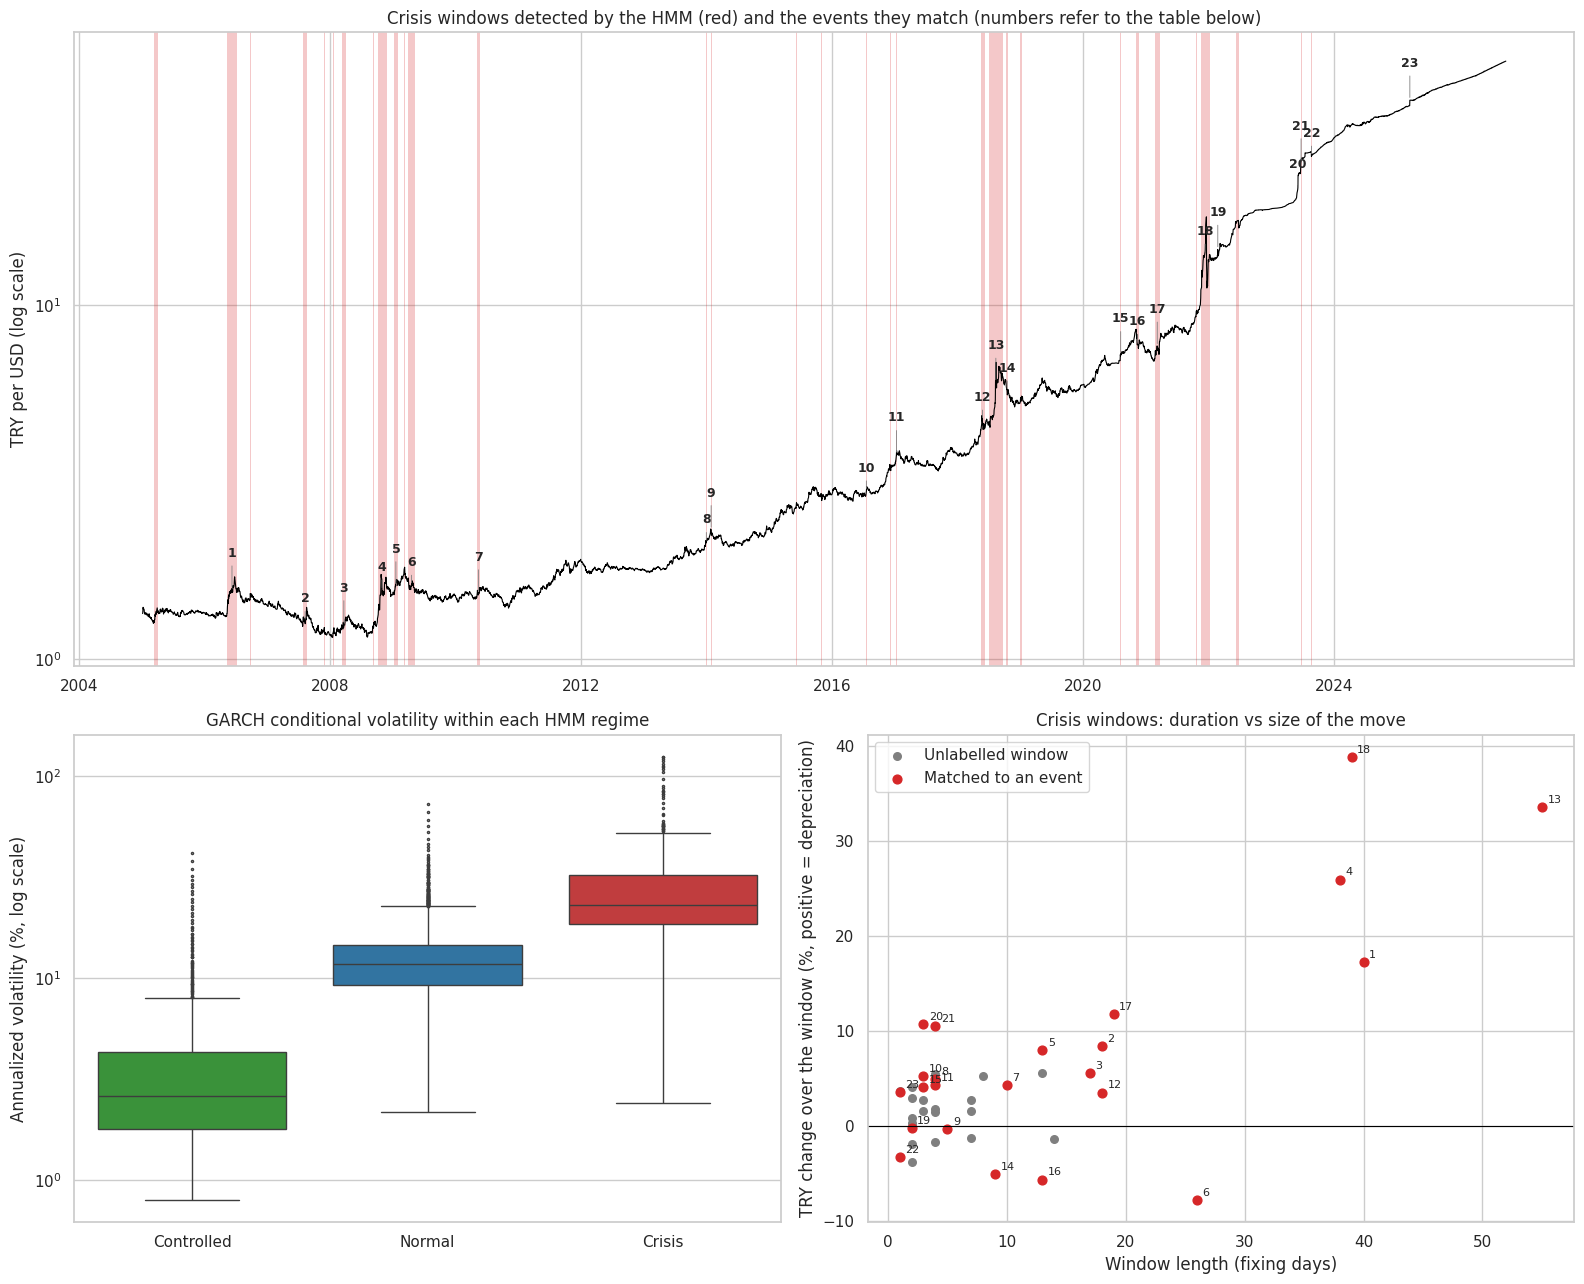

,start,end,fixing_days,crisis_days,TRY_change_%,max_daily_move_%,peak_GARCH_vol_%,event
1,2006-05-11,2006-07-05,40,34,17.25,4.62,36.37,2006 EM sell-off
2,2007-07-26,2007-08-20,18,18,8.45,4.17,34.94,Subprime crisis begins
3,2008-03-07,2008-04-02,17,17,5.63,4.47,31.47,Bear Stearns / AKP closure case
4,2008-10-02,2008-11-24,38,38,25.97,7.33,56.90,Lehman aftermath (GFC)
5,2009-01-08,2009-01-26,13,13,7.99,2.68,24.53,GFC second wave
6,2009-03-30,2009-05-07,26,26,-7.77,2.61,25.64,Post-GFC rebound
7,2010-05-06,2010-05-19,10,10,4.32,3.04,20.26,Eurozone debt crisis
8,2013-12-27,2014-01-02,4,4,5.00,3.80,20.20,Dec 2013 corruption probe
9,2014-01-24,2014-01-30,5,5,-0.32,2.29,20.01,CBRT emergency hike
10,2016-07-18,2016-07-20,3,3,5.25,2.39,15.44,Coup attempt


In [16]:
cond_vol = best_fit.conditional_volatility * np.sqrt(252)
CRISIS = STATE_NAMES.index("Crisis")
MERGE_GAP = 10

# Merge crisis days separated by short gaps into windows
crisis_idx = np.where(regime.values == CRISIS)[0]
windows = []
start = prev = crisis_idx[0]
for i in crisis_idx[1:]:
    if i - prev > MERGE_GAP:
        windows.append((start, prev))
        start = i
    prev = i
windows.append((start, prev))

days = regime.index
rows = []
for s, e in windows:
    segment = regime.iloc[s:e + 1]
    price_before = prices["TRY"].loc[:days[s]].iloc[-2]
    price_end = prices["TRY"].loc[days[e]]
    rows.append({
        "start": days[s].date(),
        "end": days[e].date(),
        "fixing_days": e - s + 1,
        "crisis_days": int((segment == CRISIS).sum()),
        "TRY_change_%": (price_end / price_before - 1) * 100,
        "max_daily_move_%": y_hmm.iloc[s:e + 1].abs().max(),
        "peak_GARCH_vol_%": cond_vol.iloc[s:e + 1].max(),
    })
crisis_windows = pd.DataFrame(rows)

EVENTS = {
    "2006-05-22": "2006 EM sell-off",
    "2007-08-09": "Subprime crisis begins",
    "2008-03-14": "Bear Stearns / AKP closure case",
    "2008-10-15": "Lehman aftermath (GFC)",
    "2009-01-15": "GFC second wave",
    "2009-04-01": "Post-GFC rebound",
    "2010-05-07": "Eurozone debt crisis",
    "2013-12-30": "Dec 2013 corruption probe",
    "2014-01-28": "CBRT emergency hike",
    "2016-07-18": "Coup attempt",
    "2017-01-10": "Jan 2017 lira sell-off",
    "2018-05-23": "May 2018 sell-off",
    "2018-08-10": "2018 currency crisis",
    "2018-10-12": "Pastor Brunson released (rally)",
    "2020-08-06": "Aug 2020 reserve concerns",
    "2020-11-09": "CBRT governor change (rally)",
    "2021-03-22": "CBRT governor dismissed",
    "2021-12-20": "Rate-cut crisis / KKM",
    "2022-02-24": "Russia invades Ukraine",
    "2023-06-07": "Post-election policy shift",
    "2023-06-22": "Smaller-than-expected hike",
    "2023-08-24": "CBRT 750bp hike",
    "2025-03-19": "Istanbul mayor detained",
}

crisis_windows["event"] = ""
unmatched = []
for date, label in EVENTS.items():
    d = pd.Timestamp(date).date()
    hit = crisis_windows[(crisis_windows["start"] <= d) & (crisis_windows["end"] >= d)]
    if len(hit):
        crisis_windows.loc[hit.index[0], "event"] = label
    else:
        unmatched.append(label)

matched = crisis_windows[crisis_windows["event"] != ""].reset_index(drop=True)
matched.index = matched.index + 1
unlabelled = crisis_windows[crisis_windows["event"] == ""]

print(f"Crisis windows detected: {len(crisis_windows)}")
print(f"Events matched: {len(EVENTS) - len(unmatched)} / {len(EVENTS)}" + (f" | unmatched: {unmatched}" if unmatched else ""))
print(f"Unlabelled windows: {len(unlabelled)} | median length {unlabelled['fixing_days'].median():.0f} days, "
      f"median |TRY move| {unlabelled['TRY_change_%'].abs().median():.1f}%")
print(f"Labelled windows  : {len(matched)} | median length {matched['fixing_days'].median():.0f} days, "
      f"median |TRY move| {matched['TRY_change_%'].abs().median():.1f}%")

# HMM regimes vs GARCH volatility
regime_labels = regime.map(dict(enumerate(STATE_NAMES)))
vol_by_regime = pd.DataFrame({"garch_vol": cond_vol.loc[regime.index], "regime": regime_labels})
top_vol_days = cond_vol >= cond_vol.quantile(0.95)
print("\nGARCH conditional volatility by HMM regime (annualized %):")
print(vol_by_regime.groupby("regime")["garch_vol"].describe().loc[STATE_NAMES].round(1))
print("\nShare of the top-5% GARCH volatility days falling in each regime:")
print(regime_labels[top_vol_days].value_counts(normalize=True).reindex(STATE_NAMES).round(3).to_string())

fig = plt.figure(figsize=(16, 13))
grid = fig.add_gridspec(2, 2, height_ratios=[1.3, 1])

ax = fig.add_subplot(grid[0, :])
try_path = prices["TRY"].loc[y_hmm.index]
ax.plot(try_path, color="black", lw=0.8)
for _, w in crisis_windows.iterrows():
    ax.axvspan(pd.Timestamp(w["start"]), pd.Timestamp(w["end"]) + pd.Timedelta(days=1),
               color="#d62728", alpha=0.25, lw=0)
for i, w in matched.iterrows():
    mid = pd.Timestamp(w["start"]) + (pd.Timestamp(w["end"]) - pd.Timestamp(w["start"])) / 2
    ax.annotate(str(i), (mid, try_path.loc[:mid].iloc[-1]), xytext=(0, 14 + 10 * (i % 2)),
                textcoords="offset points", ha="center", fontsize=9, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))
ax.set_yscale("log")
ax.set_ylabel("TRY per USD (log scale)")
ax.set_title("Crisis windows detected by the HMM (red) and the events they match (numbers refer to the table below)")

ax = fig.add_subplot(grid[1, 0])
sns.boxplot(data=vol_by_regime, x="regime", y="garch_vol", order=STATE_NAMES, hue="regime",
            palette=dict(zip(STATE_NAMES, STATE_COLORS)), legend=False, fliersize=1.5, ax=ax)
ax.set_yscale("log")
ax.set_title("GARCH conditional volatility within each HMM regime")
ax.set_ylabel("Annualized volatility (%, log scale)")
ax.set_xlabel("")

ax = fig.add_subplot(grid[1, 1])
ax.scatter(unlabelled["fixing_days"], unlabelled["TRY_change_%"], color="#7f7f7f", s=30, label="Unlabelled window")
ax.scatter(matched["fixing_days"], matched["TRY_change_%"], color="#d62728", s=40, label="Matched to an event")
for i, w in matched.iterrows():
    ax.annotate(str(i), (w["fixing_days"], w["TRY_change_%"]), xytext=(4, 3), textcoords="offset points", fontsize=8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Window length (fixing days)")
ax.set_ylabel("TRY change over the window (%, positive = depreciation)")
ax.set_title("Crisis windows: duration vs size of the move")
ax.legend()
plt.tight_layout()
plt.show()

matched.round(2)

*Caveat:* the event list was compiled after inspecting the detected windows, so the match rate is an interpretation exercise rather than an independent out-of-sample validation. The meaningful evidence is that every major window corresponds to a documented episode, and that the unlabelled windows are short and small.

## 14. Contagion: Correlations and the Dollar Factor

So far we studied TRY in isolation. Now we ask how emerging-market currencies move **together**, and whether they move together more during stress (*contagion*).

**Common window.** All 26 currencies are available from 3 January 2011, giving 4,024 daily returns from 4 January 2011 onwards.

**The dollar factor.** Much of the co-movement between currencies quoted against the dollar is simply the dollar itself moving. When the dollar strengthens broadly, all currencies weaken against it at once. To separate this from genuine EM-to-EM linkages, we build a **dollar factor** as the average return of six major developed currencies against the USD (EUR, JPY, GBP, CAD, SEK, CHF, the same currencies that make up the DXY index). We regress each EM currency on this factor and keep the residuals: the part of its movement *not* explained by the dollar.

An EM-only or all-currency average would not work as a factor: it contains the currencies being studied, and removing it mechanically pushes residual correlations towards zero.

**What we measure:**
1. The full correlation matrix, ordered by hierarchical clustering to reveal groups of currencies that move together.
2. Rolling 63-day (about one quarter) average pairwise correlation among EM currencies, before and after removing the dollar factor.
3. Average EM correlation in calm periods vs dollar-stress periods (top 10% of 21-day dollar-factor volatility).
4. TRY's rolling correlation with the other EM currencies: is TRY part of the EM pack, or does it move on its own?

*Caveat:* correlations estimated in high-volatility periods are biased upwards even without any change in the underlying linkage (Forbes and Rigobon, 2002). A rise in correlation during stress is therefore an upper bound on true contagion.

Common window: 2011-01-04 to 2026-09-29 (4,028 days, 26 currencies)

Average EM pairwise correlation: raw 0.412 | ex-dollar factor 0.209

Calm vs stress:
                             Calm (bottom 50% dollar vol)  Stress (top 10% dollar vol)
Raw EM returns                                      0.344                        0.497
EM returns ex-dollar factor                         0.193                        0.237

TRY correlation with the other EM currencies, yearly average:
date
2011    0.66
2012    0.78
2013    0.75
2014    0.67
2015    0.63
2016    0.70
2017    0.65
2018    0.45
2019    0.44
2020    0.36
2021    0.39
2022    0.25
2023    0.11
2024    0.15
2025    0.15
2026    0.22


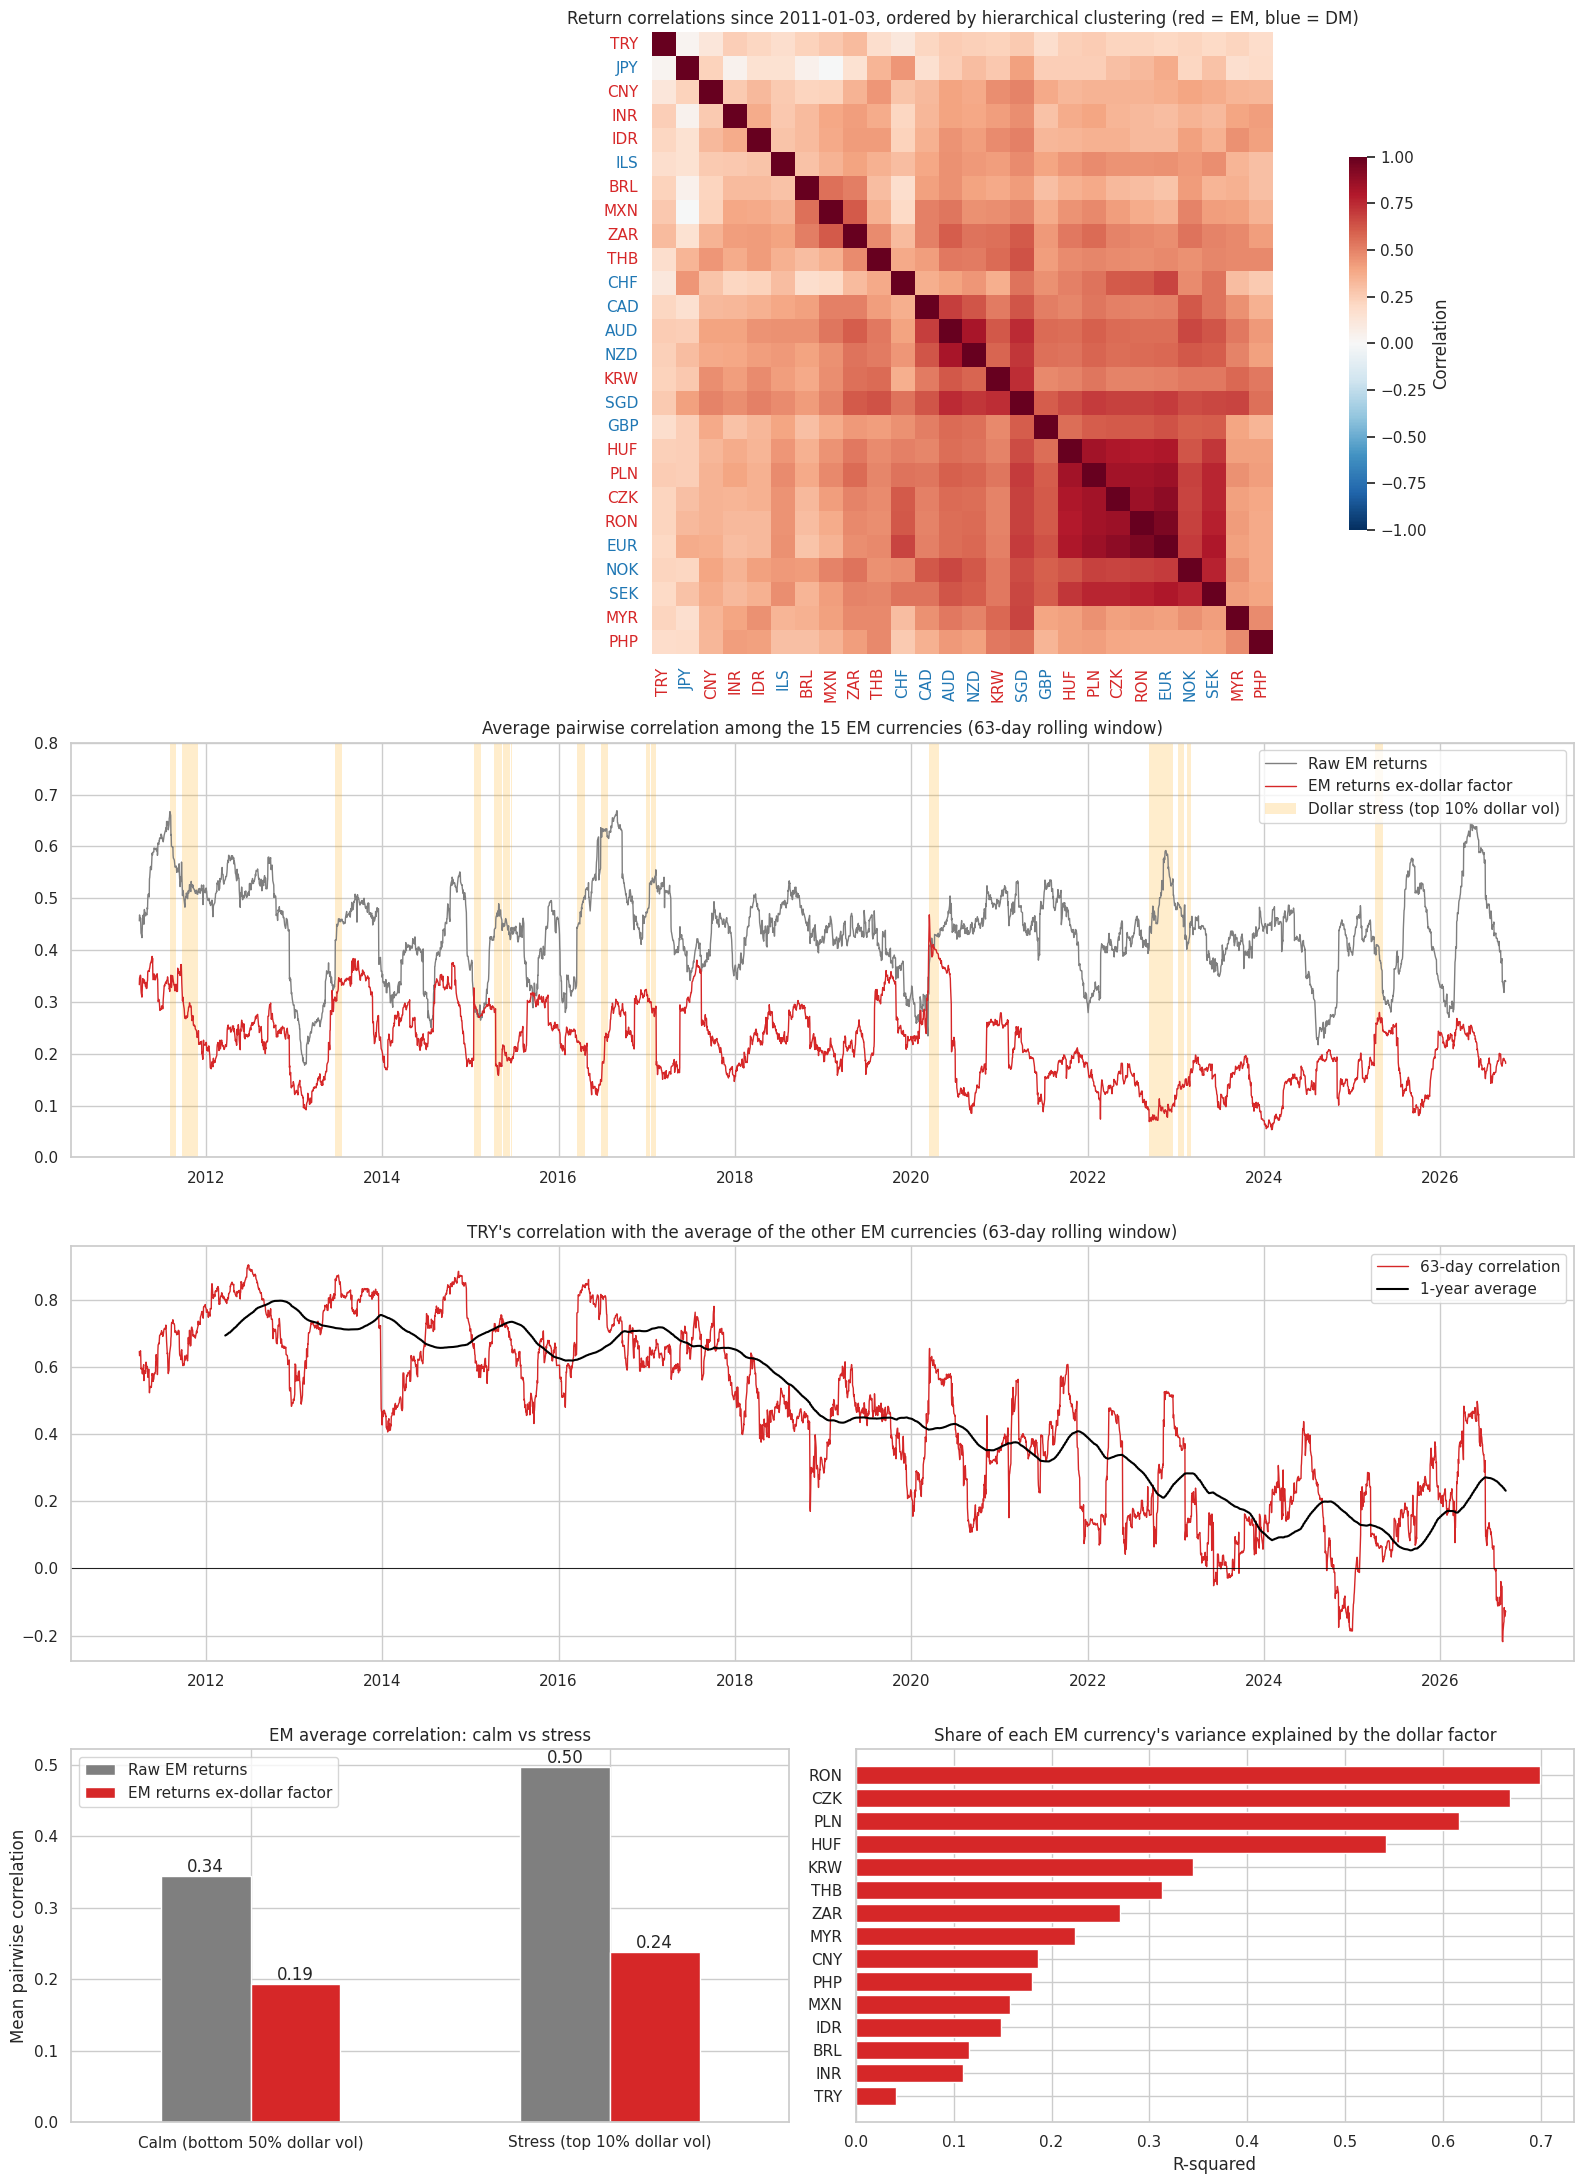

,dollar_beta,R2_dollar_factor
quote,,
RON,1.10,0.70
CZK,1.20,0.67
PLN,1.30,0.62
HUF,1.38,0.54
KRW,0.76,0.34
THB,0.52,0.31
ZAR,1.16,0.27
MYR,0.47,0.22
CNY,0.23,0.19


In [17]:
COMMON_START = "2011-01-03"
WINDOW = 63
DOLLAR_BASKET = ["EUR", "JPY", "GBP", "CAD", "SEK", "CHF"]

R = r.loc[COMMON_START:, EM + DM].dropna()
print(f"Common window: {R.index[0].date()} to {R.index[-1].date()} ({len(R):,} days, {R.shape[1]} currencies)")

# Dollar factor and EM residuals
dollar_factor = R[DOLLAR_BASKET].mean(axis=1)
betas = R[EM].apply(lambda s: np.cov(s, dollar_factor)[0, 1] / dollar_factor.var())
em_resid = R[EM] - pd.DataFrame(np.outer(dollar_factor, betas), index=R.index, columns=EM)
dollar_exposure = pd.DataFrame({
    "dollar_beta": betas,
    "R2_dollar_factor": 1 - em_resid.var() / R[EM].var(),
})

def mean_pairwise_corr(df):
    c = df.corr().values
    return c[np.triu_indices_from(c, k=1)].mean()

def rolling_mean_pairwise_corr(df, window):
    values, out = df.values, []
    upper = np.triu_indices(df.shape[1], k=1)
    for i in range(window, len(df) + 1):
        out.append(np.corrcoef(values[i - window:i].T)[upper].mean())
    return pd.Series(out, index=df.index[window - 1:])

em_corr_raw = rolling_mean_pairwise_corr(R[EM], WINDOW)
em_corr_resid = rolling_mean_pairwise_corr(em_resid, WINDOW)

em_ex_try = [c for c in EM if c != "TRY"]
try_link = R["TRY"].rolling(WINDOW).corr(R[em_ex_try].mean(axis=1))

# Calm vs stress, where stress is defined by dollar-factor volatility
dollar_vol = dollar_factor.rolling(21).std() * np.sqrt(252)
stress = dollar_vol >= dollar_vol.quantile(0.90)
calm = dollar_vol <= dollar_vol.quantile(0.50)
stress_table = pd.DataFrame({
    "Calm (bottom 50% dollar vol)": [mean_pairwise_corr(R.loc[calm, EM]), mean_pairwise_corr(em_resid.loc[calm])],
    "Stress (top 10% dollar vol)": [mean_pairwise_corr(R.loc[stress, EM]), mean_pairwise_corr(em_resid.loc[stress])],
}, index=["Raw EM returns", "EM returns ex-dollar factor"])

print(f"\nAverage EM pairwise correlation: raw {mean_pairwise_corr(R[EM]):.3f} | "
      f"ex-dollar factor {mean_pairwise_corr(em_resid):.3f}")
print("\nCalm vs stress:")
print(stress_table.round(3))
print("\nTRY correlation with the other EM currencies, yearly average:")
print(try_link.groupby(try_link.index.year).mean().round(2).to_string())

corr_full = R.corr()
cluster_order = corr_full.index[leaves_list(linkage(squareform(1 - corr_full.values, checks=False), method="average"))]

fig = plt.figure(figsize=(16, 22))
grid = fig.add_gridspec(4, 2, height_ratios=[1.5, 1, 1, 0.9])

ax = fig.add_subplot(grid[0, :])
sns.heatmap(corr_full.loc[cluster_order, cluster_order], cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={"shrink": 0.6, "label": "Correlation"})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color("#d62728" if label.get_text() in EM else "#1f77b4")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"Return correlations since {COMMON_START}, ordered by hierarchical clustering (red = EM, blue = DM)")

ax = fig.add_subplot(grid[1, :])
ax.plot(em_corr_raw, color="#7f7f7f", lw=1, label="Raw EM returns")
ax.plot(em_corr_resid, color="#d62728", lw=1, label="EM returns ex-dollar factor")
ax.fill_between(stress.index, 0, 0.8, where=stress, color="orange", alpha=0.2, lw=0,
                label="Dollar stress (top 10% dollar vol)")
ax.set_ylim(0, 0.8)
ax.set_title(f"Average pairwise correlation among the {len(EM)} EM currencies ({WINDOW}-day rolling window)")
ax.legend(loc="upper right")

ax = fig.add_subplot(grid[2, :])
ax.plot(try_link, color="#d62728", lw=1, label=f"{WINDOW}-day correlation")
ax.plot(try_link.rolling(252).mean(), color="black", lw=1.5, label="1-year average")
ax.axhline(0, color="black", lw=0.6)
ax.set_title(f"TRY's correlation with the average of the other EM currencies ({WINDOW}-day rolling window)")
ax.legend()

ax = fig.add_subplot(grid[3, 0])
stress_table.T.plot.bar(ax=ax, rot=0, color=["#7f7f7f", "#d62728"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
ax.set_title("EM average correlation: calm vs stress")
ax.set_ylabel("Mean pairwise correlation")

ax = fig.add_subplot(grid[3, 1])
r2_sorted = dollar_exposure["R2_dollar_factor"].sort_values()
ax.barh(r2_sorted.index, r2_sorted.values, color="#d62728")
ax.set_title("Share of each EM currency's variance explained by the dollar factor")
ax.set_xlabel("R-squared")
plt.tight_layout()
plt.show()

dollar_exposure.sort_values("R2_dollar_factor", ascending=False).round(2)


## 15. Conclusions

### Key findings

**1. Data.** Official central bank rates are clean (no nulls, no invalid values) but heterogeneous: 16 different rate-type combinations and mixed quoting conventions across 120 sources. The ECB reference rates are the only long, daily, single-convention source covering many emerging markets. Using them still required splicing two redenominations (TRL to TRY, ROL to RON), excluding a nine-year publication gap (ISK) and detecting six pegged currencies empirically.

**2. Returns are unpredictable; volatility is not.** Return autocorrelations are economically negligible (between -0.07 and +0.04), while absolute returns are significantly autocorrelated in all 26 currencies, and for the currencies examined in detail the autocorrelation is still clearly positive after 100 fixing days. Normality is rejected everywhere: 4-standard-deviation days occur roughly 20 to 100 times more often than a normal distribution implies.

**3. Asymmetry separates risky from safe-haven currencies.** For MXN, BRL, ZAR and TRY, depreciations raise future volatility more than appreciations. For JPY, CHF and EUR the opposite holds: volatility rises when they strengthen, consistent with flight-to-safety flows.

**4. GARCH works, with a blind spot.** EGARCH with skewed Student-t errors is clearly preferred for TRY and is the only model that passes both Kupiec and Christoffersen tests for the 99% VaR out of sample (2020-2026). The Normal-GARCH benchmark breaches almost twice as often as it should. But persistence close to 1 and very large surprises when shocks hit calm periods point to regime changes that GARCH cannot represent.

**5. Three regimes describe the lira.** A Gaussian HMM identifies a *Controlled* regime (about 2% volatility with steady depreciation, dominant since 2023), a *Normal* regime (about 10%) and a short-lived *Crisis* regime (about 44%, average duration 6.5 days). Every major crisis window corresponds to a documented domestic or global episode. On days such as 24 August 2023 and 19 March 2025 the HMM assigns the Crisis regime while GARCH volatility was still near 3%, although this comparison is ex post (see the caveats in Section 13).

**6. Contagion is mostly the dollar.** Half of the average EM correlation (0.41) is explained by a common dollar factor. In dollar-stress periods raw EM correlation rises from 0.35 to 0.50, but after removing the dollar factor only from 0.19 to 0.24, and part of that is the known volatility bias in stress-period correlations.

**7. TRY has decoupled.** The dollar factor explains only 4% of TRY's variance, the lowest of all 15 EM currencies, and TRY's correlation with the rest of the EM group fell from 0.78 (2012) to 0.11 (2023). This suggests that Turkey's major currency crises since 2018 were largely domestic rather than global.

### Limitations
- ECB reference rates are fixed once a day at 14:15 CET; intraday moves and overnight gaps are not observed.
- Official fixings are not tradable prices: there are no bid-ask spreads, so the VaR results describe risk, not a trading strategy.
- The Gaussian HMM assumes normal returns within each regime; fat tails inside the Crisis regime remain.
- HMM regimes are estimated on the full sample (ex post); they describe history rather than provide a real-time signal.
- The event list used to label crisis windows was compiled after inspecting the model output.

### Possible extensions
- Markov-switching GARCH, combining regime changes with volatility dynamics in one model.
- Multivariate volatility (DCC-GARCH) to model time-varying correlations directly.
- A real-time regime indicator using filtered probabilities from an HMM re-estimated on an expanding window.
- Applying the regime model to every EM currency and comparing crisis calendars.
- Adding macro drivers (interest-rate differentials, inflation, reserves) to explain regime transitions.

---
Thanks for reading! If this notebook helped you, please consider upvoting. Feedback and suggestions are welcome in the comments.

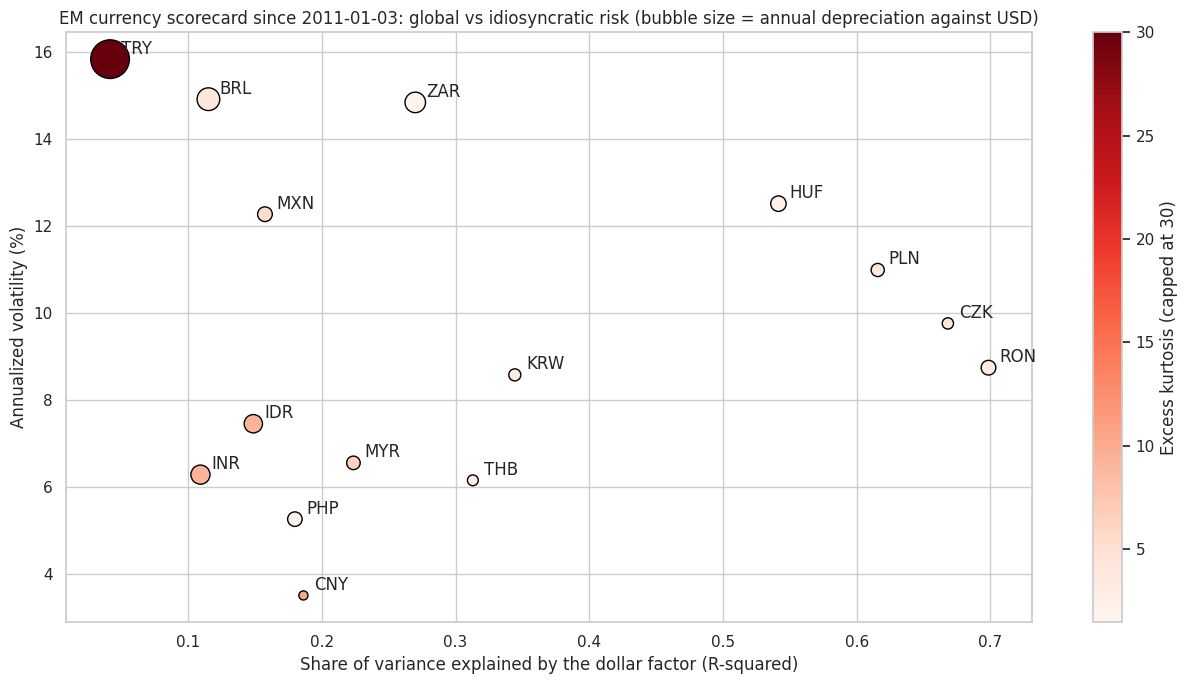

,annualized_change_%,ann_vol_%,excess_kurtosis,asymmetry_corr,R2_dollar_factor,corr_with_other_EM
TRY,24.49,15.84,260.94,0.13,0.04,0.33
BRL,7.57,14.92,3.78,0.04,0.12,0.53
ZAR,5.93,14.84,1.98,0.07,0.27,0.72
HUF,2.81,12.51,2.44,0.04,0.54,0.73
MXN,2.41,12.27,5.47,0.12,0.16,0.63
PLN,1.66,10.99,3.90,0.06,0.62,0.78
CZK,0.86,9.76,3.91,0.02,0.67,0.73
RON,2.40,8.74,3.14,0.01,0.70,0.71
KRW,1.19,8.57,3.09,-0.00,0.34,0.68
IDR,4.49,7.45,9.19,0.03,0.15,0.52


In [18]:
R_common = r.loc[COMMON_START:, EM + DM].dropna()

scorecard = pd.DataFrame({
    "annualized_change_%": annualized_change[EM],
    "ann_vol_%": R_common[EM].std() * np.sqrt(252),
    "excess_kurtosis": R_common[EM].kurt(),
    "asymmetry_corr": [R_common[c].corr(R_common[c].abs().shift(-1)) for c in EM],
    "R2_dollar_factor": dollar_exposure.loc[EM, "R2_dollar_factor"],
    "corr_with_other_EM": [R_common[c].corr(R_common[[x for x in EM if x != c]].mean(axis=1)) for c in EM],
}, index=EM).sort_values("ann_vol_%", ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))
bubble_sizes = 40 + scorecard["annualized_change_%"].clip(lower=0) * 30
points = ax.scatter(scorecard["R2_dollar_factor"], scorecard["ann_vol_%"], s=bubble_sizes,
                    c=scorecard["excess_kurtosis"].clip(upper=30), cmap="Reds", edgecolors="black")
for ccy, row in scorecard.iterrows():
    ax.annotate(ccy, (row["R2_dollar_factor"], row["ann_vol_%"]), xytext=(8, 4), textcoords="offset points")
plt.colorbar(points, ax=ax, label="Excess kurtosis (capped at 30)")
ax.set_xlabel("Share of variance explained by the dollar factor (R-squared)")
ax.set_ylabel("Annualized volatility (%)")
ax.set_title(f"EM currency scorecard since {COMMON_START}: global vs idiosyncratic risk "
             "(bubble size = annual depreciation against USD)")
plt.tight_layout()
plt.show()

scorecard.round(2)

---
Thanks for reading! If this notebook helped you, please consider upvoting. Feedback and suggestions are welcome in the comments.